# Uticaj kvaliteta i predobrade tekstualnih podataka na performanse modela za klasifikaciju spam emailova

# 1. Učitavanje i osnovna analiza skupa podataka

In [1]:
import pandas as pd

df = pd.read_csv("/Users/milicamilutinovic/Downloads/emails.csv")
df['text_raw'] = df['text']
pd.set_option('display.max_colwidth', 200)
df.head()

,text,spam,text_raw
0,Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo ...,1,Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo ...
1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or ...,1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or ...
2,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended t...",1,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended t..."
3,Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 33...,1,Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 33...
4,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death...",1,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death..."


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      5728 non-null   str  
 1   spam      5728 non-null   int64
 2   text_raw  5728 non-null   str  
dtypes: int64(1), str(2)
memory usage: 17.1 MB


Shape: (5728, 3)

Distribucija klasa:
spam
0    4360
1    1368
Name: count, dtype: int64
spam
0    0.761
1    0.239
Name: proportion, dtype: float64


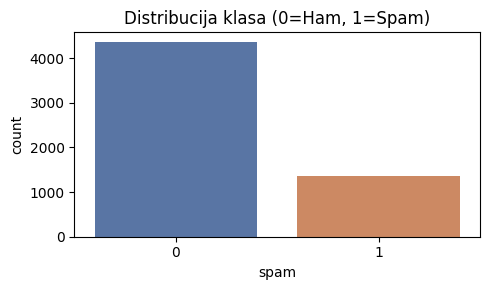

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Shape:", df.shape)
print("\nDistribucija klasa:")
print(df['spam'].value_counts())
print(df['spam'].value_counts(normalize=True).round(3))

# Vizuelizacija distribucije klasa
plt.figure(figsize=(5, 3))
sns.countplot(x='spam', data=df, hue='spam', palette=['#4C72B0','#DD8452'], legend=False)
plt.title("Distribucija klasa (0=Ham, 1=Spam)")
plt.tight_layout()
plt.show()

# 2. Analiza kvaliteta teksta

### Provera duplikata

In [4]:
num_duplicates = df['text'].duplicated().sum()
print(f"Ukupan broj duplikata: {num_duplicates}")

Ukupan broj duplikata: 33


In [5]:
duplicates = df[df['text'].duplicated(keep=False)].sort_values('text')
duplicates[['text', 'spam']].head(6)

,text,spam
3165,"Subject: * special notification * aurora version 5 . 5 release , what ' s new ? iv friends : i spoken with most of you over the last few weeks regarding the new version of aurora due to be rel...",0
5716,"Subject: * special notification * aurora version 5 . 5 release , what ' s new ? iv friends : i spoken with most of you over the last few weeks regarding the new version of aurora due to be rel...",0
1417,"Subject: day off tuesday stinson , i would like to take a day off tomorrow ( tuesday , april 10 ) . i need to register my son to elementary school and send my cars to service . my cell number ...",0
2473,"Subject: day off tuesday stinson , i would like to take a day off tomorrow ( tuesday , april 10 ) . i need to register my son to elementary school and send my cars to service . my cell number ...",0
1801,"Subject: departure of grant masson the research group : it is with a deep sense of regret that i announce that grant masson will be leaving the research group and enron , effective today . gra...",0
2260,"Subject: departure of grant masson the research group : it is with a deep sense of regret that i announce that grant masson will be leaving the research group and enron , effective today . gra...",0


In [6]:
df_before=df.copy()
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Pre: {len(df_before)}")
print(f"Posle: {len(df)}")

Pre: 5728
Posle: 5695


### Dužina dokumenata

In [7]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

stats = df.groupby('spam')[['word_count','char_count']].agg(['mean','median','std']).round(1)
stats.index = ['Ham','Spam']
print("Statistike dužine dokumenata:")
display(stats)

def ttr(text):
    tokens = str(text).split()
    return len(set(tokens)) / len(tokens) if tokens else 0

df['ttr'] = df['text'].apply(ttr)
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

Statistike dužine dokumenata:


word_count               char_count                
           mean median    std       mean  median     std
Ham       346.3  239.0  407.2     1634.2  1122.0  1965.0
Spam      266.4  139.5  451.5     1317.3   693.5  2271.4

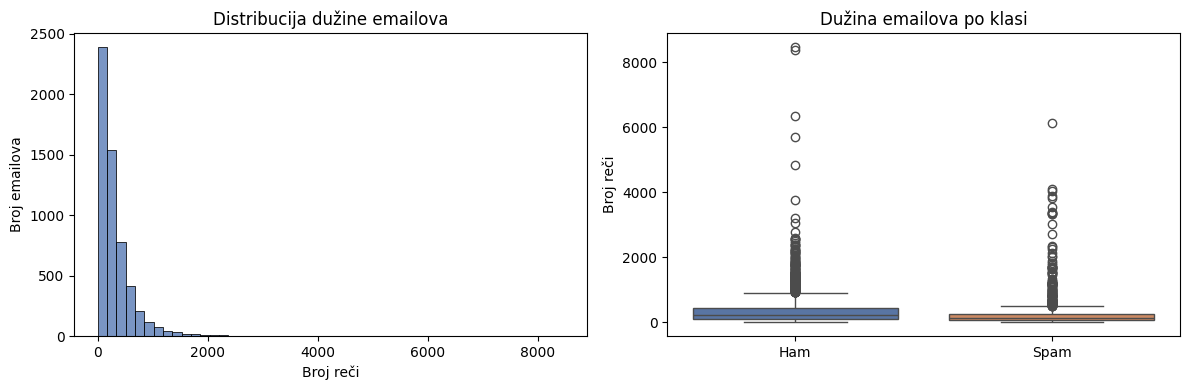

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["word_count"], bins=50, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribucija dužine emailova")
axes[0].set_xlabel("Broj reči")
axes[0].set_ylabel("Broj emailova")

sns.boxplot(
    x="spam",
    y="word_count",
    hue="spam",
    data=df,
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Dužina emailova po klasi")
axes[1].set_xlabel("")
axes[1].set_ylabel("Broj reči")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["Ham", "Spam"])

plt.tight_layout()
plt.show()

- Distribucija je izraženo desno asimetrična (right-skewed)
- Većina emailova ima manje od ~500 tokena
- Postoji mali broj ekstremno dugih emailova (do 8000+ tokena)

In [9]:
df.groupby("spam")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0,4327.0,346.253293,407.188262,2.0,119.0,239.0,439.5,8477.0
1,1368.0,266.432749,451.461674,4.0,79.0,139.5,251.0,6129.0


Analiza distribucije dužine emailova pokazuje izraženu desnu asimetriju, pri čemu većina poruka sadrži manje od 500 tokena, dok mali broj ekstremno dugih poruka značajno povećava varijansu raspodele. Prosečna dužina ham poruka (345 tokena) veća je od prosečne dužine spam poruka (266 tokena), dok medijana dodatno potvrđuje da su spam poruke u tipičnom slučaju kraće. Visoke vrednosti standardne devijacije u obe klase (406 i 451) ukazuju na veliku disperziju i prisustvo outlier-a. Ovi rezultati sugerišu da dužina dokumenta sama po sebi nije dovoljan diskriminativni atribut, ali predstavlja važnu strukturnu karakteristiku koja utiče na stabilnost reprezentacije i raspodelu frekvencija u BoW i TF-IDF modelima.

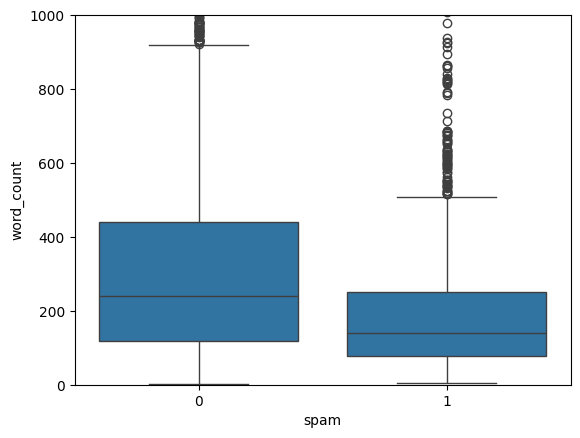

In [10]:
sns.boxplot(x="spam", y="word_count", data=df)
plt.ylim(0, 1000)
plt.show()

Boxplot potvrđuje da su ham poruke (0) u proseku duže od spam poruka (1). Medijana ham emailova iznosi oko 239 reči, dok spam emailovi imaju medijanu
oko 140 reči. Spam klasa pokazuje veći broj outlier-a u gornjem delu raspodele, što ukazuje da pojedini spam emailovi mogu biti ekstremno dugi. Visok IQR (Interquartile Range) u obe klase ukazuje na veliku varijabilnost dužine, što znači da dužina dokumenta sama po sebi nije pouzdan diskriminativni atribut

### Vocabulary Size (|V|)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Ukupan vokabular
vectorizer_all = CountVectorizer()
X_all = vectorizer_all.fit_transform(df["text"])
all_vocab = set(vectorizer_all.get_feature_names_out())

# Spam vokabular
vectorizer_spam = CountVectorizer()
X_spam = vectorizer_spam.fit_transform(df[df["spam"] == 1]["text"])
spam_vocab = set(vectorizer_spam.get_feature_names_out())

# Ham vokabular
vectorizer_ham = CountVectorizer()
X_ham = vectorizer_ham.fit_transform(df[df["spam"] == 0]["text"])
ham_vocab = set(vectorizer_ham.get_feature_names_out())

print("Vocabulary Size: ")
print(f"Ukupan vokabular:     {len(all_vocab):,} tokena")
print(f"Spam vokabular:       {len(spam_vocab):,} tokena")
print(f"Ham vokabular:        {len(ham_vocab):,} tokena")
print(f"Presek (zajednički):  {len(spam_vocab & ham_vocab):,} tokena")
print(f"Samo u spamu:         {len(spam_vocab - ham_vocab):,} tokena")
print(f"Samo u hamu:          {len(ham_vocab - spam_vocab):,} tokena")

Vocabulary Size: 
Ukupan vokabular:     37,303 tokena
Spam vokabular:       18,774 tokena
Ham vokabular:        27,074 tokena
Presek (zajednički):  8,545 tokena
Samo u spamu:         10,229 tokena
Samo u hamu:          18,529 tokena


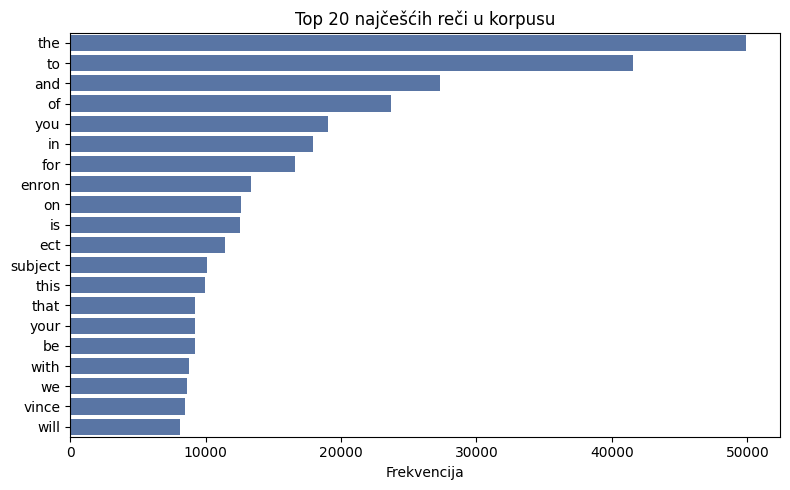

In [12]:
# Suma frekvencija po rečima
sum_words = X_all.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer_all.vocabulary_.items()
]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

top_words = pd.DataFrame(words_freq[:20], columns=["reč", "frekvencija"])

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_words,
    x="frekvencija",
    y="reč",
    color="#4C72B0"
)

plt.title("Top 20 najčešćih reči u korpusu")
plt.xlabel("Frekvencija")
plt.ylabel("")

plt.tight_layout()
plt.show()

Ukupan vokabular korpusa iznosi 37.303 jedinstvena tokena, pri čemu ham poruke imaju značajno bogatiji vokabular (27.074) u odnosu na spam (18.774), a svega
8.545 tokena je zajedničko za obe klase. Dominacija stop-reči poput "the", "to" i "and" u top 20 najfrekventnijih reči, zajedno sa domenski specifičnim tokenima kao što su "enron" i "vince", potvrđuje Zipfovu raspodelu i ukazuje na potrebu za uklanjanjem stop-reči pre modeliranja.

### Zipova raspodela frekvencija

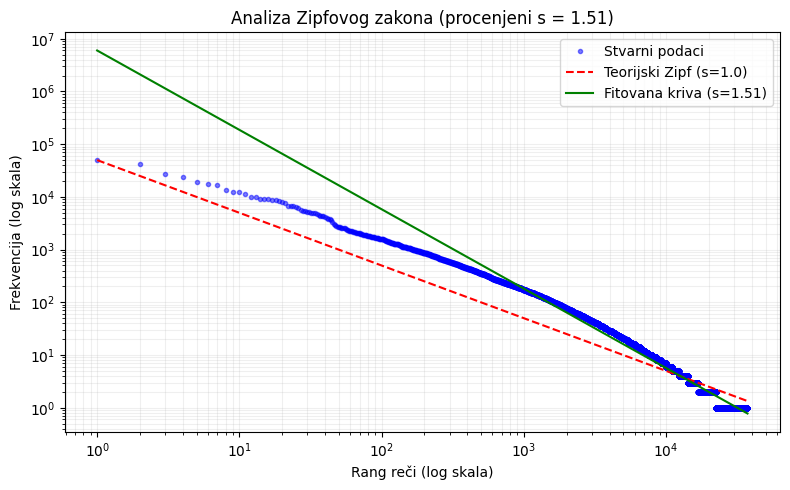

In [13]:
import numpy as np

vec_all  = CountVectorizer(); vec_all.fit_transform(df['text'])
X_all = vec_all.transform(df['text'])
word_freqs = sorted(zip(vec_all.get_feature_names_out(),
                        np.asarray(X_all.sum(axis=0)).flatten()),
                    key=lambda x: x[1], reverse=True)

freqs = [f for _, f in word_freqs]
ranks = np.arange(1, len(freqs)+1)

# Teorijska Zipf linija (s=1.0)
C = freqs[0]
zipf_theoretical = C / (ranks ** 1.0)

# Fitovana kriva (procena stvarnog s)
log_ranks = np.log(ranks)
log_freqs = np.log(freqs)
m, b = np.polyfit(log_ranks, log_freqs, 1)
s_est = -m
zipf_fitted = np.exp(b) * (ranks ** m)

plt.figure(figsize=(8, 5))
plt.loglog(ranks, freqs, 'b.', label="Stvarni podaci", alpha=0.5)
plt.loglog(ranks, zipf_theoretical, 'r--', label="Teorijski Zipf (s=1.0)")
plt.loglog(ranks, zipf_fitted, 'g-', label=f"Fitovana kriva (s={s_est:.2f})")
plt.title(f"Analiza Zipfovog zakona (procenjeni s = {s_est:.2f})")
plt.xlabel("Rang reči (log skala)")
plt.ylabel("Frekvencija (log skala)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

Procenjeni Zipf eksponent iznosi s = 1.51, što je nešto više od teorijske vrednosti s = 1.0. Ovo je tipično za domenski specifične korpuse, email, tekst sadrži veliki broj retkih, jednokratnih tokena (nazivi, greške u kucanju, obfuskovane spam reči) koji ubrzavaju opadanje frekvencije u repu raspodele. Fitovana kriva (zelena) bolje opisuje stvarne podatke od teorijskog Zipfa, posebno u oblasti reči sa visokim rangom. Long-tail efekat je izražen: više od 40% vokabulara pojavljuje se samo jednom u celom korpusu.

In [14]:
vocab_size = len(all_vocab)

rare_words = sum(1 for word, freq in words_freq if freq == 1)

print("Broj reči sa frekvencijom 1:", rare_words)
print("Procenat retkih reči: {:.2%}".format(rare_words / vocab_size))

Broj reči sa frekvencijom 1: 15001
Procenat retkih reči: 40.21%


long-tail efekat

### Lexical Diversity

Lexical diversity (TTR: Type-Token Ratio) meri odnos jedinstvenih reči prema ukupnom broju reči u dokumentu. Vrednost bliska 1 znači visoku raznovrsnost vokabulara, dok vrednost bliska 0 ukazuje na mnogo ponavljanja. Negativna korelacija potvrđuje da TTR zavisi od dužine teksta.

In [15]:
def lexical_diversity(text):
    tokens = str(text).split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df["lexical_diversity"] = df["text"].apply(lexical_diversity)


In [16]:
print("Prosečan TTR po klasi:")
print(df.groupby('spam')['ttr'].mean().rename({0:'Ham', 1:'Spam'}))
print(f"\nKorelacija word_count: {df['word_count'].corr(df['ttr']):.3f}")

Prosečan TTR po klasi:
spam
Ham     0.532537
Spam    0.623567
Name: ttr, dtype: float64

Korelacija word_count: -0.612


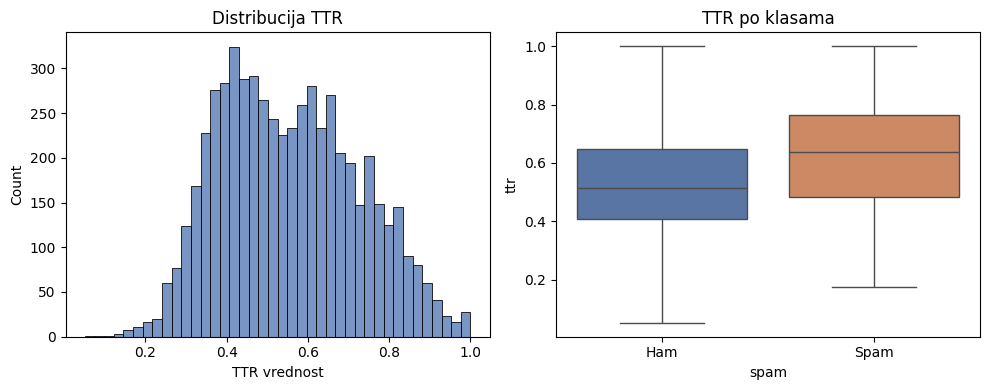

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['ttr'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title("Distribucija TTR"); axes[0].set_xlabel("TTR vrednost")

sns.boxplot(x='spam', y='ttr', data=df,
            hue="spam" ,palette=['#4C72B0','#DD8452'], ax=axes[1], legend=False)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Ham','Spam'])
axes[1].set_title("TTR po klasama")
plt.tight_layout(); plt.show()

Spam poruke imaju višu prosečnu TTR vrednost (0.62) u odnosu na ham poruke (0.53), što ukazuje na veći udeo jedinstvenih reči, verovatno zbog maskiranja i veštačkog variranja reči radi zaobilaženja filtera. Međutim, značajna negativna korelacija između dužine dokumenta i TTR (r = -0.61) upozorava da su spam poruke u proseku kraće, pa deo razlike u TTR vrednostima može biti posledica dužine, a ne sadržaja. TTR je koristan signal, ali ga treba koristiti u kombinaciji sa drugim atributima.

### Analiza šuma

In [18]:
import re
def count_urls(t):    return len(re.findall(r'http\S+|www\.\S+', str(t)))
def count_html(t):    return len(re.findall(r'<[^>]+>', str(t)))
def count_caps(t):    return sum(1 for w in str(t).split() if w.isupper() and len(w)>2)
def count_special(t): return len(re.findall(r'[!$%&*@#]', str(t)))
def count_nums(t):    return len(re.findall(r'\b\d+\b', str(t)))
def has_obfusc(t):    return int(bool(re.search(r'[a-z]\d[a-z]', str(t).lower())))

for fn, col in [(count_urls,'url_count'), (count_html,'html_count'),
                (count_caps,'caps_count'), (count_special,'special_chars'),
                (count_nums,'number_count'), (has_obfusc,'has_obfuscation')]:
    df[col] = df['text'].apply(fn)

noise_cols = ['url_count','html_count','caps_count','special_chars','number_count','has_obfuscation']
noise_stats = df.groupby('spam')[noise_cols].mean().round(2)
noise_stats.index = ['Ham','Spam']
print("Prosečne vrednosti indikatora šuma po klasi:")
display(noise_stats)

Prosečne vrednosti indikatora šuma po klasi:


,url_count,html_count,caps_count,special_chars,number_count,has_obfuscation
Ham,0.0,0.0,0.0,5.96,17.15,0.0
Spam,0.0,0.0,0.0,6.39,10.94,0.0


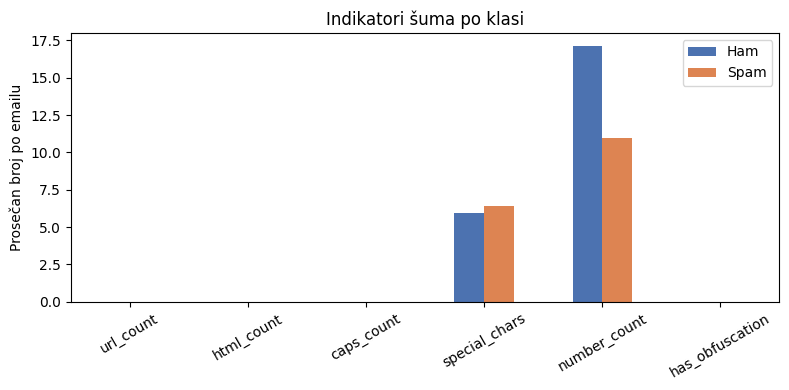

In [19]:
noise_stats.T.plot(kind='bar', figsize=(8,4), color=['#4C72B0','#DD8452'])
plt.title("Indikatori šuma po klasi")
plt.ylabel("Prosečan broj po emailu")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

Analiza indikatora šuma pokazuje da su specijalni znaci i numerički tokeni najizraženiji oblici šuma u obe klase. Ham poruke sadrže veći prosečan broj numeričkih tokena (17.14 vs 10.94), što je očekivano s obzirom na poslovnu prirodu legitimnih emailova koji često sadrže datume, cifre i finansijske podatke. Spam poruke pokazuju nešto veću upotrebu specijalnih znakova (6.39 vs 5.98). URL-ovi, HTML tagovi, CAPS reči i obfuskacija imaju zanemarljivu prosečnu vrednost, što sugeriše da je dataset već delimično prečišćen. Izolovani indikatori šuma nisu dovoljni za pouzdanu klasifikaciju, ali u kombinaciji sa tekstualnim reprezentacijama mogu poboljšati performanse modela.

### Korelaciona matrica

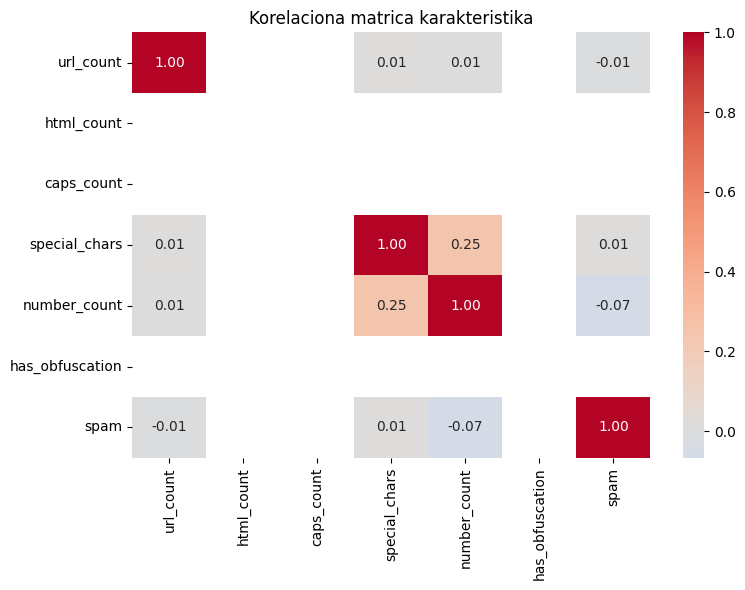

In [20]:
corr_matrix = df[noise_cols + ['spam']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Korelaciona matrica karakteristika")
plt.tight_layout()
plt.show()

Korelaciona matrica pokazuje da su sve pojedinačne karakteristike šuma slabo povezane sa spam klasom. Najizraženija međusobna korelacija primećena je između broja numeričkih tokena i specijalnih znakova (r ≈ 0.25), ali njihova povezanost sa klasom spam ostaje minimalna.
Ovo ukazuje da izolovane karakteristike nisu dovoljne za pouzdanu klasifikaciju, već je potrebna kombinacija više atributa i model koji može da uhvati kompleksnije obrasce.

# 3. Predobrada teksta

### Normalizacija

Normalizacija teksta obuhvata skup transformacija kojima se smanjuje varijabilnost zapisa bez gubitka semantički relevantnih informacija. Umesto potpunog uklanjanja elemenata poput URL-ova i email adresa, koristi se strategija zamene specijalnim tokenima (<URL>, <EMAIL>, <NUMBER>), čime se zadržava informacija o njihovom prisustvu uz istovremeno smanjenje dimenzionalnosti vokabulara.

In [21]:
import unicodedata
def normalize_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKC", text)        # unicode normalizacija
    text = re.sub(r"<[^>]+>", " ", text)              # uklanjanje HTML tagova
    text = re.sub(r"http[s]?://\S+|www\.\S+", " <URL> ", text)    # URL token
    text = re.sub(r"[\w.+-]+@[\w-]+\.[\w.]+", " <EMAIL> ", text)  # EMAIL token
    text = re.sub(r"\b\d+\.?\d*\b", " <NUMBER> ", text)           # NUMBER token
    text = text.lower()                               # lowercase
    text = re.sub(r"[^\w\s<>]", " ", text)            # uklanjanje interpunkcije
    text = re.sub(r"\s+", " ", text).strip()          # visak razmaka
    return text

df["text_normalized"] = df["text"].apply(normalize_text)

# Uticaj na vokabular

v1 = len(CountVectorizer().fit(df["text"]).vocabulary_)
v2 = len(CountVectorizer().fit(df["text_normalized"]).vocabulary_)
print(f"Vokabular pre normalizacije : {v1:,} tokena")
print(f"Vokabular posle normalizacije: {v2:,} tokena")
print(f"Redukcija: {(1 - v2/v1)*100:.1f}%")

Vokabular pre normalizacije : 37,303 tokena
Vokabular posle normalizacije: 33,688 tokena
Redukcija: 9.7%


In [22]:
num_dup_norm = df['text_normalized'].duplicated().sum()
print(f"Broj duplikata (normalized): {num_dup_norm}")

Broj duplikata (normalized): 196


In [23]:
dup_norm = df[df['text_normalized'].duplicated(keep=False)] \
             .sort_values('text_normalized')

dup_norm[['text', 'text_normalized', 'spam']].head(6)

,text,text_normalized,spam
4218,"Subject: 2 - survey / information email 5 - 7 - 01 current notes user : to ensure that you experience a successful migration from notes to outlook , it is necessary to gather individual user in...",subject <number> survey information email <number> <number> <number> current notes user to ensure that you experience a successful migration from notes to outlook it is necessary to gather individ...,0
5680,"Subject: 2 - survey / information email 5 - 7 - 01 current notes user : to ensure that you experience a successful migration from notes to outlook , it is necessary to gather individual user inf...",subject <number> survey information email <number> <number> <number> current notes user to ensure that you experience a successful migration from notes to outlook it is necessary to gather individ...,0
3313,Subject: 1 - urgent - outlook email notification ( new ) outlook email notification your date of migration is : may 7 th you will be unable to send e - mail unless you take the following action...,subject <number> urgent outlook email notification new outlook email notification your date of migration is may <number> th you will be unable to send e mail unless you take the following action p...,0
5524,Subject: 1 - urgent - outlook email notification ( new ) outlook email notification your date of migration is : may 7 th you will be unable to send e - mail unless you take the following action...,subject <number> urgent outlook email notification new outlook email notification your date of migration is may <number> th you will be unable to send e mail unless you take the following action p...,0
3281,"Subject: 4 - urgent - owa please print this now . current notes user : reasons for using outlook web access ( owa ) 1 . once your mailbox has been migrated from notes to outlook , the outlook ...",subject <number> urgent owa please print this now current notes user reasons for using outlook web access owa <number> once your mailbox has been migrated from notes to outlook the outlook client ...,0
4383,"Subject: 4 - urgent - owa please print this now . current notes user : reasons for using outlook web access ( owa ) 1 . once your mailbox has been migrated from notes to outlook , the outlook c...",subject <number> urgent owa please print this now current notes user reasons for using outlook web access owa <number> once your mailbox has been migrated from notes to outlook the outlook client ...,0


In [24]:
df_before_n=df.copy()
df = df.drop_duplicates(subset='text_normalized')

print(f"Pre: {len(df_before_n)}")
print(f"Posle: {len(df)}")
print(f"Uklonjeno: {len(df_before_n) - len(df)}")

df = df.reset_index(drop=True)

Pre: 5695
Posle: 5499
Uklonjeno: 196


In [25]:
df = df.reset_index(drop=True)

In [26]:
print("Da li ima duplikata:", df['text_normalized'].duplicated().sum())

Da li ima duplikata: 0


### Tokenizacija

Tokenizacija je proces razlaganja teksta na manje jedinice, tokene. Poredimo tri pristupa: word-level (podela po rečima), subword (duže reči se dele na prefikse i sufikse), i sentence-level tokenizaciju.

In [27]:
def tokenize_words(text):
    return re.findall(r"\b[a-zA-Z]+\b", str(text).lower())

def tokenize_subword(text):
    tokens = tokenize_words(text)
    result = []
    for t in tokens:
        if len(t) <= 4:
            result.append(t)
        else:
            result.extend([t[:3] + "##", "##" + t[3:]])
    return result

def tokenize_sentences(text):
    sentences = re.split(r"[.!?]+", str(text))
    return [s.strip() for s in sentences if len(s.strip()) > 10]

word_counts    = df["text"].apply(lambda x: len(tokenize_words(x)))
subword_counts = df["text"].apply(lambda x: len(tokenize_subword(x)))
sent_counts    = df["text"].apply(lambda x: len(tokenize_sentences(x)))

print(f"Word tokenizacija, prosečan broj tokena: {word_counts.mean():.1f}")
print(f"Subword tokenizacija, prosečan broj tokena: {subword_counts.mean():.1f}")
print(f"Sentence tokenizacija,  prosečan broj rečenica: {sent_counts.mean():.1f}")
print(f"Povećanje subword vs word: {(subword_counts.mean()/word_counts.mean()-1)*100:.1f}%")

sample_text = df["text"].iloc[0]

print("\nOriginal (skraćeno):")
print(sample_text[:200])
print("\nWord tokens:", tokenize_words(sample_text)[:15])
print("\nSentence tokens:", tokenize_sentences(sample_text)[:3])
print("\nSubword tokens:", tokenize_subword(sample_text)[:15])


Word tokenizacija, prosečan broj tokena: 227.6
Subword tokenizacija, prosečan broj tokena: 327.1
Sentence tokenizacija,  prosečan broj rečenica: 15.1
Povećanje subword vs word: 43.7%

Original (skraćeno):
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , st

Word tokens: ['subject', 'naturally', 'irresistible', 'your', 'corporate', 'identity', 'lt', 'is', 'really', 'hard', 'to', 'recollect', 'a', 'company', 'the']

Sentence tokens: ['Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier', 'we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good 

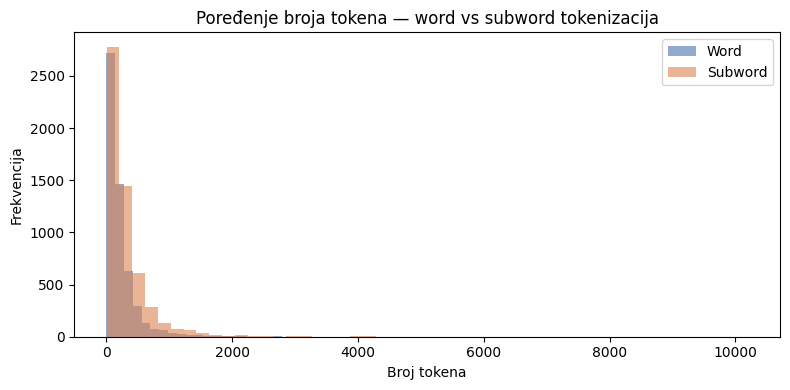

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(word_counts, bins=50, alpha=0.6, label="Word", color="#4C72B0")
plt.hist(subword_counts, bins=50, alpha=0.6, label="Subword", color="#DD8452")
plt.title("Poređenje broja tokena — word vs subword tokenizacija")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.legend()
plt.tight_layout()
plt.show()

Poređenje tokenizacionih pristupa pokazuje jasne razlike u granularnosti reprezentacije. Word tokenizacija generiše prosečno 227.8 tokena po dokumentu i predstavlja najjednostavniji pristup, ali ne može da obradi reči koje nisu viđene tokom treninga. Subword tokenizacija povećava broj tokena za 43.7% (327.4 prosečno) razlaganjem dužih reči na prefikse i sufikse, što omogućava bolju pokrivenost retkih i namerno iskrivljenih reči tipičnih za spam emailove *(npr. "irresistible" → "irr##" + "##esistible")*. Sentence tokenizacija pokazuje da prosečan email sadrži oko 15 rečenica. Za klasične ML modele poput TF-IDF koristićemo word tokenizaciju, dok subword pristup postaje ključan kod transformer modela poput BERT-a.

### Stemming i Lematizacija

Stemming i lematizacija su tehnike morfološke normalizacije koje svode reči na njihovu osnovnu formu. Stemming (Porter) agresivno odseče sufikse i brz je, ali može proizvesti nepostojeće reči. Lematizacija koristi rečnik i vraća stvarnu osnovu reči, ali je sporija.

In [29]:
from nltk.stem import PorterStemmer
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
from tqdm import tqdm
stemmer = PorterStemmer()
def apply_stemming(text):
    tokens = text.split()
    return " ".join([stemmer.stem(w) for w in tokens if w.isalpha()])

texts = df["text_normalized"].tolist()
lemmatized = []
for doc in tqdm(nlp.pipe(texts, batch_size=500)):
    lemmatized.append(" ".join([t.lemma_ for t in doc if t.is_alpha]))
df["text_lemmatized"] = lemmatized
df["text_stemmed"] = df["text_normalized"].apply(apply_stemming)

v_norm  = len(CountVectorizer().fit(df["text_normalized"]).vocabulary_)
v_stem  = len(CountVectorizer().fit(df["text_stemmed"]).vocabulary_)
v_lemma = len(CountVectorizer().fit(df["text_lemmatized"]).vocabulary_)

5499it [03:22, 27.10it/s]


In [30]:
print(f"Normalizovan  : {v_norm:,} tokena")
print(f"Stemming      : {v_stem:,} tokena  (redukcija: {(1-v_stem/v_norm)*100:.1f}%)")
print(f"Lematizacija  : {v_lemma:,} tokena  (redukcija: {(1-v_lemma/v_norm)*100:.1f}%)")

Normalizovan  : 33,688 tokena
Stemming      : 25,693 tokena  (redukcija: 23.7%)
Lematizacija  : 29,147 tokena  (redukcija: 13.5%)


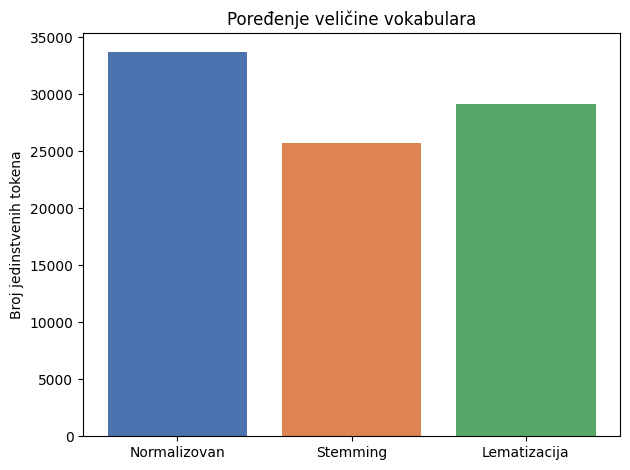

In [31]:
plt.bar(["Normalizovan", "Stemming", "Lematizacija"],
        [v_norm, v_stem, v_lemma],
        color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Poređenje veličine vokabulara")
plt.ylabel("Broj jedinstvenih tokena")
plt.tight_layout()
plt.show()

In [32]:
# primer transformacije
sample_words = ["marketing", "clicking", "running", "easily", "companies", "saving", "better"]

print("Primer transformacije reči:\n")
print(f"{'Originalna':<15} {'Stemming':<15} {'Lematizacija':<15}")
print("-" * 45)
for word in sample_words:
    stemmed = stemmer.stem(word)
    lemma = nlp(word)[0].lemma_
    print(f"{word:<15} {stemmed:<15} {lemma:<15}")

Primer transformacije reči:

Originalna      Stemming        Lematizacija   
---------------------------------------------
marketing       market          marketing      
clicking        click           click          
running         run             run            
easily          easili          easily         
companies       compani         company        
saving          save            save           
better          better          well           


Stemming postiže veću redukciju vokabulara (23.7%) svođenjem reči na njihov koren odsecanjem sufiksa, ali može proizvesti nepostojeće oblike reči *(npr. "marketing" → "market", "easily" → "easili")*. Lematizacija je konzervativnija (13.5% redukcija) i uvek vraća stvarnu osnovnu formu rečikoristeći rečnik *(npr. "running" → "run", "better" → "well"*). Za zadatak klasifikacije spam emailova stemming je prihvatljiv izbor zbog brzine i dovoljne redukcije dimenzionalnosti, dok lematizacija daje čistiji vokabular na račun veće računske složenosti.

### Uklanjanje stop-reči

Stop-reči su visokofrekventne reči bez semantičke vrednosti za klasifikaciju (the, is, at, and...). Njihovim uklanjanjem smanjujemo dimenzionalnost i fokusiramo model na diskriminativne tokene.

In [33]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
def remove_stopwords(text):
    tokens = text.split()
    return " ".join([t for t in tokens
                     if t not in ENGLISH_STOP_WORDS and t.isalpha()])

df["text_no_stop"] = df["text_normalized"].apply(remove_stopwords)

len_before = df["text_normalized"].apply(lambda x: len(x.split())).mean()
len_after  = df["text_no_stop"].apply(lambda x: len(x.split())).mean()

print(f"Prosečna dužina pre  uklanjanja stop-reči: {len_before:.1f} tokena")
print(f"Prosečna dužina posle uklanjanja stop-reči: {len_after:.1f} tokena")
print(f"Redukcija dužine: {(1 - len_after/len_before)*100:.1f}%")

Prosečna dužina pre  uklanjanja stop-reči: 250.2 tokena
Prosečna dužina posle uklanjanja stop-reči: 130.4 tokena
Redukcija dužine: 47.9%


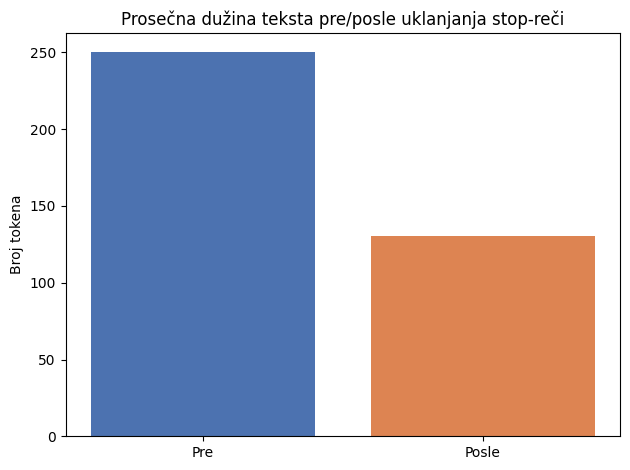

In [34]:
plt.bar(["Pre", "Posle"], [len_before, len_after],
        color=["#4C72B0", "#DD8452"])
plt.title("Prosečna dužina teksta pre/posle uklanjanja stop-reči")
plt.ylabel("Broj tokena")
plt.tight_layout()
plt.show()

### Analiza posle text preprocessing-a

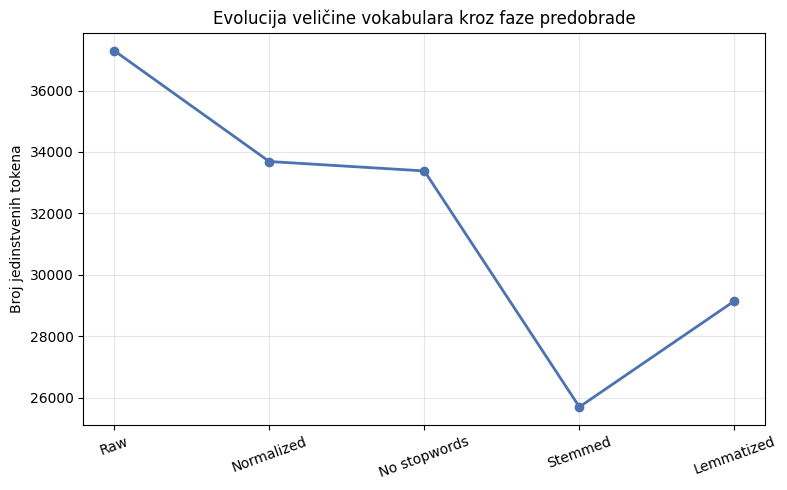

In [35]:
stages = {
    "Raw":          len(CountVectorizer().fit(df["text_raw"]).vocabulary_),
    "Normalized":   len(CountVectorizer().fit(df["text_normalized"]).vocabulary_),
    "No stopwords": len(CountVectorizer().fit(df["text_no_stop"]).vocabulary_),
    "Stemmed":      len(CountVectorizer().fit(df["text_stemmed"]).vocabulary_),
    "Lemmatized":   len(CountVectorizer().fit(df["text_lemmatized"]).vocabulary_),
}

plt.figure(figsize=(8, 5))
plt.plot(list(stages.keys()), list(stages.values()), marker="o", color="#4C72B0", linewidth=2)
plt.title("Evolucija veličine vokabulara kroz faze predobrade")
plt.ylabel("Broj jedinstvenih tokena")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Graf prikazuje progresivno smanjenje vokabulara kroz svaku fazu predobrade. `Normalizacija` (Unicode, lowercase, zamena URL/EMAIL/NUMBER tokena) smanjujevokabular sa 37.303 na 33.688 tokena. Uklanjanje `stop-reči` donosi dodatnu redukciju, dok `stemming` postiže najagresivnije smanjenje na 25.693 tokena odsecanjem sufiksa. `Lematizacija` daje nešto veći vokabular od stemminga (29.147) jer čuva stvarne osnove reči. Ukupna redukcija od sirovog teksta do stemovanog iznosi oko 31%, što direktno smanjuje dimenzionalnost feature matrice i potencijalno ubrzava treniranje modela.

## Finalni pipeline

In [36]:
def preprocess_pipeline(text, stemming=False, lemmatization=False,
                         remove_stops=True):
    # normalizacija
    text = normalize_text(text)
    
    # morfološka normalizacija
    if stemming:
        text = apply_stemming(text)
    elif lemmatization:
        doc = nlp(text)
        text = " ".join([t.lemma_ for t in doc if t.is_alpha])
    
    # uklanjanje stop-reci
    if remove_stops:
        text = remove_stopwords(text)

    return text

df['text_raw'] = df['text']

if 'text_normalized' not in df.columns:
    df['text_normalized'] = df['text'].apply(
        lambda x: preprocess_pipeline(x, False, False, False))

if 'text_no_stop' not in df.columns:
    df['text_no_stop'] = df['text'].apply(
        lambda x: preprocess_pipeline(x, False, False, True))

if 'text_stemmed' not in df.columns:
    df['text_stemmed'] = df['text'].apply(
        lambda x: preprocess_pipeline(x, True, False, True))

if 'text_lemmatized' not in df.columns:
    df['text_lemmatized'] = df['text'].apply(
        lambda x: preprocess_pipeline(x, False, True, True))

print("\nProsečna dužina po verziji (broj tokena):")
for col in ['text_raw', 'text_normalized', 'text_no_stop', 'text_stemmed', 'text_lemmatized']:
    avg = df[col].apply(lambda x: len(str(x).split())).mean()
    print(f" {col:<20} {avg:.1f} tokena")


Prosečna dužina po verziji (broj tokena):
 text_raw             326.3 tokena
 text_normalized      250.2 tokena
 text_no_stop         130.4 tokena
 text_stemmed         227.6 tokena
 text_lemmatized      243.3 tokena


# 4. Data Augmentation

Data augmentation je tehnika proširivanja trening skupa veštačkim generisanjem novih primera. Cilj je smanjiti klasnu neravnotezu, dataset sadrži 76% ham i 24% spam emailova.

In [37]:
import nltk
from nltk.corpus import wordnet

# Tri EDA tehnike
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            s = lemma.name().replace("_", " ").lower()
            if s != word:
                synonyms.add(s)
    return list(synonyms)

def synonym_replacement(text, n=2):
    words = text.split()
    candidates = [w for w in set(words) if get_synonyms(w)]
    if not candidates:
        return text
    chosen = np.random.choice(candidates, min(n, len(candidates)), replace=False)
    new_words = words.copy()
    for word in chosen:
        syns = get_synonyms(word)
        if syns:
            new_words = [np.random.choice(syns) if w == word else w for w in new_words]
    return " ".join(new_words)

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) <= 5:
        return text
    new_words = [w for w in words if np.random.random() > p]
    return " ".join(new_words) if new_words else words[0]

def random_swap(text, n=2):
    words = text.split()
    if len(words) < 4:
        return text
    new_words = words.copy()
    for _ in range(n):
        i, j = np.random.choice(len(words), 2, replace=False)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return " ".join(new_words)

# primer
demo = "get free offer now click here best price money"
print("Original:             ", demo)
print("Synonym replacement:  ", synonym_replacement(demo))
print("Random deletion:      ", random_deletion(demo))
print("Random swap:          ", random_swap(demo))

Original:              get free offer now click here best price money
Synonym replacement:   produce free offer now get across here best price money
Random deletion:       get free now click here best money
Random swap:           get free offer now price here money click best


EDA  (Easy Data Augmentation) obuhvata tri tehnike za veštačko proširivanje trening skupa. `Synonym replacement` zamenjuje nasumično izabrane reči njihovim sinonimima iz WordNet rečnika *(npr. "get" → "drive")*. `Random deletion` nasumično uklanja reči sa verovatnoćom p=0.1, čime se simulira šum u tekstu. `Random swap` menja pozicije dvaju nasumično izabranih reči. Sve tri tehnike čuvaju originalnu klasu emaila i koriste se isključivo za proširivanje manjinske klase (spam) kako bi se smanjila klasna neravnoteža u trening skupu.

In [38]:
spam_df = df[df['spam'] == 1].copy()
ham_df  = df[df['spam'] == 0].copy()

print(f"Pre augmentacije: Ham: {len(ham_df)}, Spam: {len(spam_df)}, Odnos: {len(ham_df)/len(spam_df):.2f}:1")

target_spam = 2000
to_generate = target_spam - len(spam_df)
spam_texts  = spam_df['text_no_stop'].tolist()

augmented_texts  = []
augmented_labels = []
methods = ['synonym', 'deletion', 'swap']

for i in range(to_generate):
    base = np.random.choice(spam_texts)
    method = np.random.choice(methods)
    if method == 'synonym':
        aug = synonym_replacement(base, n=3)
    elif method == 'deletion':
        aug = random_deletion(base, p=0.1)
    else:
        aug = random_swap(base, n=2)
    augmented_texts.append(aug)
    augmented_labels.append(1)

aug_df = pd.DataFrame({'text_no_stop': augmented_texts, 'spam': augmented_labels})
df_augmented = pd.concat([df[['text_no_stop','spam']], aug_df], ignore_index=True)

print(f"Posle augmentacije: Ham: {len(df_augmented[df_augmented['spam']==0])}, "
      f"Spam: {len(df_augmented[df_augmented['spam']==1])}, "
      f"Odnos: {len(df_augmented[df_augmented['spam']==0])/len(df_augmented[df_augmented['spam']==1]):.2f}:1")


Pre augmentacije: Ham: 4133, Spam: 1366, Odnos: 3.03:1
Posle augmentacije: Ham: 4133, Spam: 2000, Odnos: 2.07:1


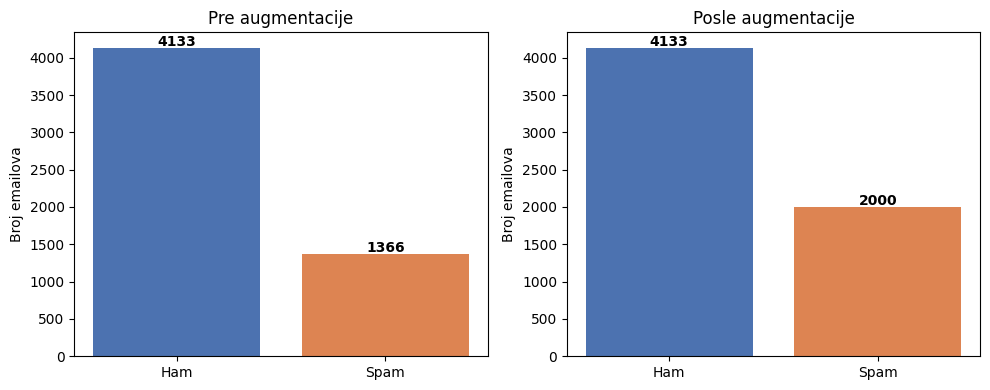

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(axes,
                            [[len(ham_df), len(spam_df)],
                             [len(df_augmented[df_augmented['spam']==0]),
                              len(df_augmented[df_augmented['spam']==1])]],
                            ["Pre augmentacije", "Posle augmentacije"]):
    ax.bar(['Ham', 'Spam'], data, color=['#4C72B0', '#DD8452'])
    ax.set_title(title)
    ax.set_ylabel("Broj emailova")
    for i, v in enumerate(data):
        ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Augmentacijom spam klase broj spam emailova povećan je sa 1368 na 2000, čime je odnos klasa smanjen sa 3.19:1 na 2.18:1. Važna napomena: augmentovani primeri dodaju se isključivo u trening skup, test skup ostaje originalan kako bi evaluacija bila fer i nepristrasna. Uticaj augmentacije na performanse modela biće izmeren u sekciji klasifikacije poređenjem rezultata sa i bez augmentacije na istom test skupu.

# 5. Reprezentacija teksta i uticaj predobrade

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Train/test split, koristimo text_no_stop kao glavnu verziju
df = df.drop_duplicates(subset='text_no_stop')
X = df['text_no_stop']
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Test split")
print(f"Trening skup : {len(X_train)} emailova ({y_train.mean()*100:.1f}% spam)")
print(f"Test skup    : {len(X_test)} emailova ({y_test.mean()*100:.1f}% spam)")

Train/Test split
Trening skup : 4396 emailova (24.9% spam)
Test skup    : 1100 emailova (24.8% spam)


In [41]:
overlap = set(X_train).intersection(set(X_test))
print(f"Overlap: {len(overlap)}")

Overlap: 0


## 5.1 Bag-of-Words 
Bag-of-Words (BoW) predstavlja svaki dokument kao vektor frekvencija reči, pri čemu se gubi informacija o redosledu. Rezultujuća matrica je izrazito retka (sparse) što direktno odražava raznovrsnost korpusa.

BoW matrica shape : (4396, 5000)
Sparsity          : 98.64%


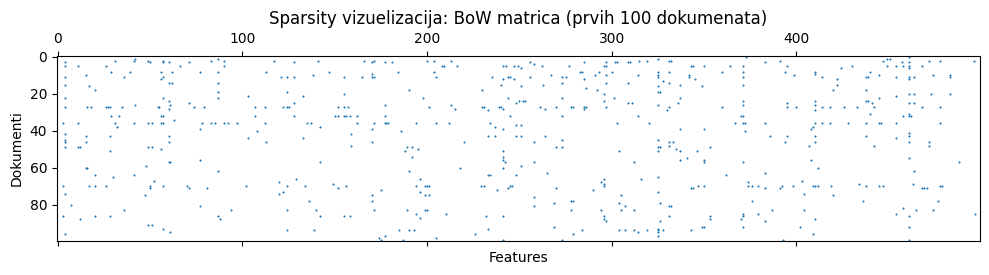

In [42]:
bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

sparsity = 1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])
print(f"BoW matrica shape : {X_train_bow.shape}")
print(f"Sparsity          : {sparsity:.2%}")

plt.figure(figsize=(10, 4))
plt.spy(X_train_bow[:100, :500], markersize=0.5)
plt.title("Sparsity vizuelizacija: BoW matrica (prvih 100 dokumenata)")
plt.xlabel("Features")
plt.ylabel("Dokumenti")
plt.tight_layout()
plt.show()

BoW matrica dimenzija 4582×5000 ima sparsity od 98.64%, što znači da je svega 1.36% elemenata nenula. Vizuelizacija to potvrđuje, svaki dokument koristi samo mali podskup od 5000 raspoloživih tokena. Ovako visoka retkost je tipična za tekstualne podatke i direktna je posledica Zipfove raspodele: većina reči se pojavljuje u malom broju dokumenata. Retke matrice zahtevaju posebnu pažnju pri izboru modela, algoritmi poput Naive Bayes i LinearSVC su prirodno prilagođeni radu sa sparse reprezentacijama.

## 5.2 TF-IDF

TF-IDF (Term Frequency — Inverse Document Frequency) dodeljuje veću težinu rečima koje su česte u dokumentu ali retke u korpusu, čime se smanjuje uticaj stop-reči i povećava diskriminativnost reprezentacije u odnosu na BoW.

In [43]:
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

density  = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"TF-IDF matrica shape : {X_train_tfidf.shape}")
print(f"Sparsity             : {1-density:.2%}")

TF-IDF matrica shape : (4396, 5000)
Sparsity             : 98.46%


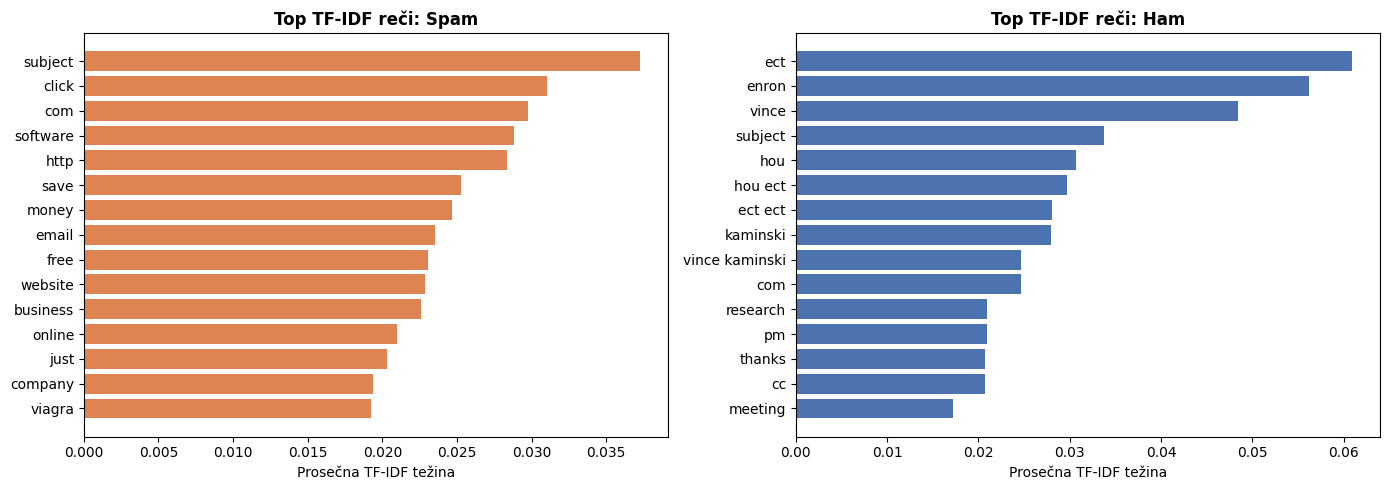

In [44]:
feature_names = tfidf_vec.get_feature_names_out()

def top_tfidf_words(X, y, label, n=15):
    mask = (y == label).values
    mean_tfidf = X[mask].mean(axis=0)
    mean_tfidf = np.asarray(mean_tfidf).flatten()
    top_idx = mean_tfidf.argsort()[-n:][::-1]
    return [(feature_names[i], mean_tfidf[i]) for i in top_idx]

spam_words = top_tfidf_words(X_train_tfidf, y_train, 1)
ham_words  = top_tfidf_words(X_train_tfidf, y_train, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, words, title, color in zip(
        axes,
        [spam_words, ham_words],
        ["Top TF-IDF reči: Spam", "Top TF-IDF reči: Ham"],
        ['#DD8452', '#4C72B0']):
    labels = [w for w, _ in words][::-1]
    values = [v for _, v in words][::-1]
    ax.barh(labels, values, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Prosečna TF-IDF težina")
plt.tight_layout()
plt.show()

TF-IDF vizuelizacija jasno razdvaja diskriminativne reči po klasama. Spam emailovi imaju visoke težine za reči poput *"click", "money", "free", "save" i "software"*,  tipične reči promotivnih i prevarantskih poruka. Ham emailovi dominiraju domenski specifičnim tokenima poput *"enron", "vince", "kaminski" i bigramima "hou ect", "vince kaminski"*, što ukazuje na poslovnu prirodu legitimnih emailova. Prisustvo bigrama u ham klasi potvrđuje vrednost ngram_range=(1,2), fraze nose više informacije od pojedinačnih reči.

### Najčešće reči po klasi

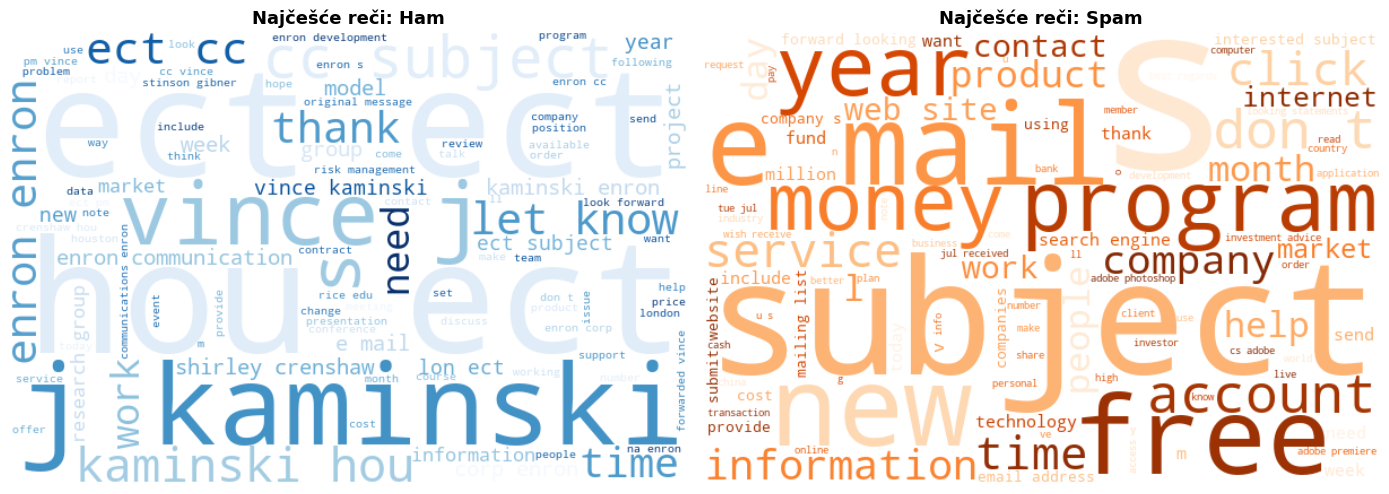

In [45]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (label, title) in enumerate([(0, 'Ham'), (1, 'Spam')]):
    tekst = " ".join(df[df["spam"] == label]["text_no_stop"].values)
    wc = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Blues' if label == 0 else 'Oranges',
                   max_words=100).generate(tekst)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Najčešće reči: {title}', fontsize=13, fontweight='bold')
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 5.3 Word2Vec 

Word2Vec trenira plitku neuralnu mrežu na lokalnom kontekstu reči i generiše guste vektore koji kodiraju semantičke odnose. Dokument se reprezentuje usrednjavanjem vektora svih reči (mean pooling). Glavni nedostatak je nemogućnost reprezentacije reči koje nisu viđene tokom treninga (OOV problem).

In [46]:
from gensim.models import Word2Vec

sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences, vector_size=100, window=5,
                     min_count=2, workers=4, seed=42)

def doc_to_w2v(text, model, dim=100):
    tokens = text.split()
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_train_w2v = np.array([doc_to_w2v(t, w2v_model) for t in X_train])
X_test_w2v  = np.array([doc_to_w2v(t, w2v_model) for t in X_test])

all_tokens = set(" ".join(X_train).split())
oov = sum(1 for t in all_tokens if t not in w2v_model.wv)
print(f"Word2Vec shape   : {X_train_w2v.shape}")
print(f"OOV tokeni       : {oov:,} ({oov/len(all_tokens):.1%})")

Word2Vec shape   : (4396, 100)
OOV tokeni       : 12,282 (41.1%)


Word2Vec generiše 100-dimenzionalne vektore za svaki dokument usrednjavanjem vektora pojedinačnih reči. Problem je što 41.1% tokena iz trening skupa nije pokriveno modelom (OOV: Out of Vocabulary), što znači da se za te reči koristi nulti vektor. U kontekstu spam emailova ovo je posebno problematično jer spameri često koriste namerno iskrivljene reči koje Word2Vec nije video tokom treninga. Visok procenat OOV tokena direktno utiče na kvalitet reprezentacije i potencijalno na performanse klasifikatora, ovaj problem rešava FastText u sledećem koraku.

## 5.4 FastText

FastText proširuje Word2Vec uvođenjem subword informacija, svaka reč se razlaže na n-grame karaktera. Ovo omogućava generisanje vektora čak i za reči koje nisu viđene tokom treninga, što je posebno važno za spam emailove koji sadrže namerno iskrivljene reči. FastText postiže 100% pokrivenost vokabulara.


In [47]:
from gensim.models import FastText

ft_model = FastText(sentences, vector_size=100, window=5,
                    min_count=2, workers=4, seed=42)

def doc_to_ft(text, model, dim=100):
    tokens = text.split()
    vecs = [model.wv[t] for t in tokens]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_train_ft = np.array([doc_to_ft(t, ft_model) for t in X_train])
X_test_ft  = np.array([doc_to_ft(t, ft_model) for t in X_test])

print(f"FastText shape : {X_train_ft.shape}")
print(f"Pokrivenost    : 100% (subword omogućava pokrivanje svih tokena)")

# Demonstracija OOV
oov_words = ['v1agra', 'fr33', 'cl1ck', 'moneey']
print("\nFastText OOV demonstracija:")
for word in oov_words:
    similar = ft_model.wv.most_similar(word, topn=2)
    print(f"  '{word}' → {[w for w, _ in similar]}")

FastText shape : (4396, 100)
Pokrivenost    : 100% (subword omogućava pokrivanje svih tokena)

FastText OOV demonstracija:
  'v1agra' → ['viagra', 'iot']
  'fr33' → ['fr', 'fro']
  'cl1ck' → ['clck', 'ck']
  'moneey' → ['havemore', 'mone']


FastText postiže 100% pokrivenost vokabulara zahvaljujući subword reprezentaciji, svaka reč se razlaže na n-grame karaktera, pa model može da generiše vektor čak i za reči koje nisu viđene tokom treninga. Demonstracija pokazuje da model ispravno prepoznaje namerno iskrivljene spam reči: 'v1agra' se mapira na 'viagra', a 'cl1ck' na 'clck', što znači da subword informacija uspešno hvata sličnost između originalne i iskrivljene forme. Ovo čini FastText robusnijim od Word2Vec u domenu spam detekcije gde je maskiranje reči česta taktika zaobilaženja filtera.

## 5.5 Sentence Transformers (aktuelni pristup) 
Sentence Transformers su moderni transformer modeli koji generišu semantički bogate reprezentacije celih rečenica ili dokumenata. Za razliku od Word2Vec i FastText koji usrednjavaju vektore reči, Sentence Transformers koriste pažnju (attention) da uhvate kontekst cele sekvence. Koristimo pretreniran model 'all-MiniLM-L6-v2' koji je optimizovan za semantičku sličnost i klasifikaciju teksta.

In [48]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_st = st_model.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True
)

X_test_st = st_model.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Sentence Transformer shape:", X_train_st.shape)

/Users/milicamilutinovic/ml_nlp/tf_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/69 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Sentence Transformer shape: (4396, 384)


### 5.6 Fine-tuned BERT (DistilBERT)

DistilBERT je lakša verzija BERT-a (40% manji, 60% brži) ali zadržava 97% BERT performansi. Fine-tuning na našem datasetu omogućava kontekstualne reprezentacije specifične za spam domen.

In [49]:
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments, DistilBertModel)
from torch.utils.data import Dataset
import torch

# tokanizer
tokenizer_bert = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

# Dataset klasa 
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

# Koristimo text_raw 
train_dataset = EmailDataset(
    X_train.values, y_train.values, tokenizer_bert
)
test_dataset = EmailDataset(
    X_test.values, y_test.values, tokenizer_bert
)

print(f"Train dataset: {len(train_dataset)} primera")
print(f"Test dataset : {len(test_dataset)} primera")

# model
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# tr arg
training_args = TrainingArguments(
    output_dir='./bert_spam',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    load_best_model_at_end=False,
    report_to='none'
)

# treiner
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

print("Treniranje DistilBERT modela...")
trainer.train()

# evaluacija
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

preds_output = trainer.predict(test_dataset)
logits = preds_output.predictions
y_pred_bert = logits.argmax(axis=1)
y_prob_bert = torch.softmax(
    torch.tensor(logits), dim=1
).numpy()[:, 1]

acc_bert = accuracy_score(y_test, y_pred_bert)
f1_bert  = f1_score(y_test, y_pred_bert)
auc_bert = roc_auc_score(y_test, y_prob_bert)

print(f"\nDistilBERT rezultati:")
print(f"  Accuracy : {acc_bert:.4f}")
print(f"  F1       : {f1_bert:.4f}")
print(f"  AUC      : {auc_bert:.4f}")

#  Izvlačenje embedding reprezentacije

bert_encoder = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert_encoder.eval()

def get_bert_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        encoded = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        )
        with torch.no_grad():
            output = model(**encoded)
        # [CLS] token kao reprezentacija dokumenta
        cls_embeddings = output.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.numpy())
    return np.vstack(all_embeddings)

print("\nGenerisanje BERT embedding reprezentacija...")
X_train_bert = get_bert_embeddings(
    X_train.values, tokenizer_bert, bert_encoder
)
X_test_bert = get_bert_embeddings(
    X_test.values, tokenizer_bert, bert_encoder
)

print(f"BERT embedding shape: {X_train_bert.shape}")

2026-03-25 11:45:39.023618: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train dataset: 4396 primera
Test dataset : 1100 primera


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/milicamilutinovic/ml_nlp/tf_env/lib/python3.11/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Treniranje DistilBERT modela...


  0%|          | 0/825 [00:00<?, ?it/s]

...

{'eval_loss': 0.046781186014413834, 'eval_runtime': 96.2816, 'eval_samples_per_second': 11.425, 'eval_steps_per_second': 0.364, 'epoch': 2.0}
{'loss': 0.0071, 'grad_norm': 0.02406850829720497, 'learning_rate': 1.5517241379310346e-05, 'epoch': 2.18}
{'loss': 0.0056, 'grad_norm': 0.008277039043605328, 'learning_rate': 1.206896551724138e-05, 'epoch': 2.36}
{'loss': 0.0025, 'grad_norm': 18.4227352142334, 'learning_rate': 8.620689655172414e-06, 'epoch': 2.55}
{'loss': 0.0005, 'grad_norm': 0.009640009142458439, 'learning_rate': 5.172413793103448e-06, 'epoch': 2.73}
{'loss': 0.0053, 'grad_norm': 0.025124965235590935, 'learning_rate': 1.724137931034483e-06, 'epoch': 2.91}


  0%|          | 0/35 [00:00<?, ?it/s]

{'eval_loss': 0.05722808092832565, 'eval_runtime': 92.7261, 'eval_samples_per_second': 11.863, 'eval_steps_per_second': 0.377, 'epoch': 3.0}
{'train_runtime': 4904.1833, 'train_samples_per_second': 2.689, 'train_steps_per_second': 0.168, 'train_loss': 0.07231596410048731, 'epoch': 3.0}


  0%|          | 0/35 [00:00<?, ?it/s]


DistilBERT rezultati:
  Accuracy : 0.9891
  F1       : 0.9779
  AUC      : 0.9993

Generisanje BERT embedding reprezentacija...
BERT embedding shape: (4396, 768)


# 6. Klasifikacija i evaluacija

In [50]:
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import StandardScaler

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    try:
        prob = model.predict_proba(X_te)[:,1]
    except:
        prob = model.decision_function(X_te)
    auc = roc_auc_score(y_te, prob)
    return {'Model': name, 'Accuracy': round(acc,4),
            'F1': round(f1,4), 'AUC': round(auc,4)}

### Baseline

In [51]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_tfidf, y_train)
y_pred_dummy = dummy.predict(X_test_tfidf)

print("Baseline (majority class)")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}")

Baseline (majority class)
Accuracy : 0.7518
F1       : 0.0000


### Klasični ML modeli na TF-IDF

Naive Bayes               Acc=0.9836  F1=0.9665  AUC=0.9988
Complement NB             Acc=0.9818  F1=0.9643  AUC=0.9988
Logistic Regression       Acc=0.9836  F1=0.9662  AUC=0.9993
LinearSVC                 Acc=0.9955  F1=0.9908  AUC=0.9998
Random Forest             Acc=0.9845  F1=0.9687  AUC=0.9988


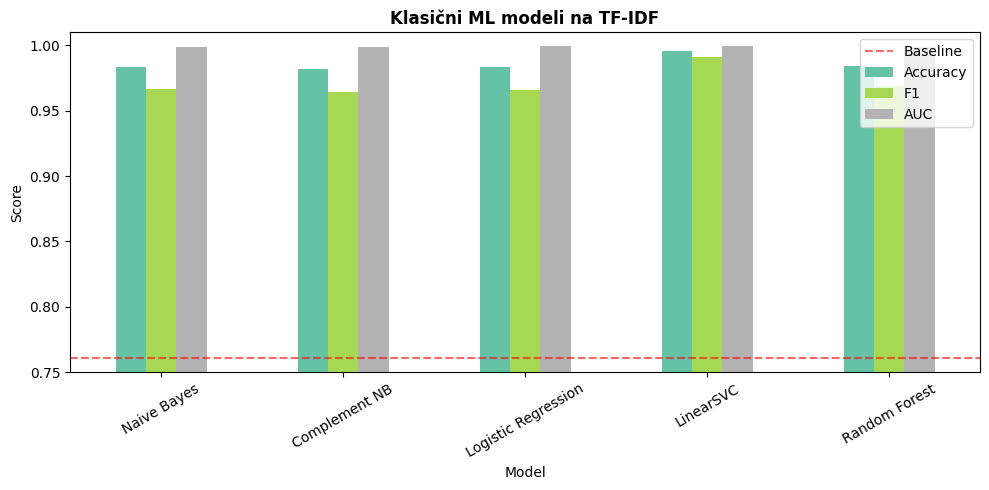


Najbolji model: LinearSVC


In [52]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
ml_models = [
    ('Naive Bayes',        MultinomialNB()),
    ('Complement NB',      ComplementNB()),
    ('Logistic Regression',LogisticRegression(max_iter=1000, random_state=42)),
    ('LinearSVC',          LinearSVC(max_iter=1000, random_state=42)),
    ('Random Forest',      RandomForestClassifier(n_estimators=100, random_state=42)),
]

ml_results = []
for name, model in ml_models:
    res = evaluate_model(name, model,
                         X_train_tfidf, X_test_tfidf,
                         y_train, y_test)
    ml_results.append(res)
    print(f"{name:<25} Acc={res['Accuracy']:.4f}  "
          f"F1={res['F1']:.4f}  AUC={res['AUC']:.4f}")

ml_df = pd.DataFrame(ml_results)

# Vizuelizacija
ml_df.set_index('Model')[['Accuracy','F1','AUC']].plot(
    kind='bar', figsize=(10,5), colormap='Set2'
)
plt.title("Klasični ML modeli na TF-IDF", fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0.75, 1.01)
plt.axhline(y=0.7609, color='red', linestyle='--',
            label='Baseline', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# best
best_name = ml_df.loc[ml_df['F1'].idxmax(), 'Model']
print(f"\nNajbolji model: {best_name}")

### Poređenje reprezentacija

BoW                       Acc=0.9873  F1=0.9746  AUC=0.9970
TF-IDF                    Acc=0.9955  F1=0.9908  AUC=0.9998
Word2Vec                  Acc=0.9800  F1=0.9599  AUC=0.9967
FastText                  Acc=0.9727  F1=0.9453  AUC=0.9944
Sentence Transformers     Acc=0.9636  F1=0.9275  AUC=0.9911
BERT embeddings           Acc=0.9755  F1=0.9501  AUC=0.9973


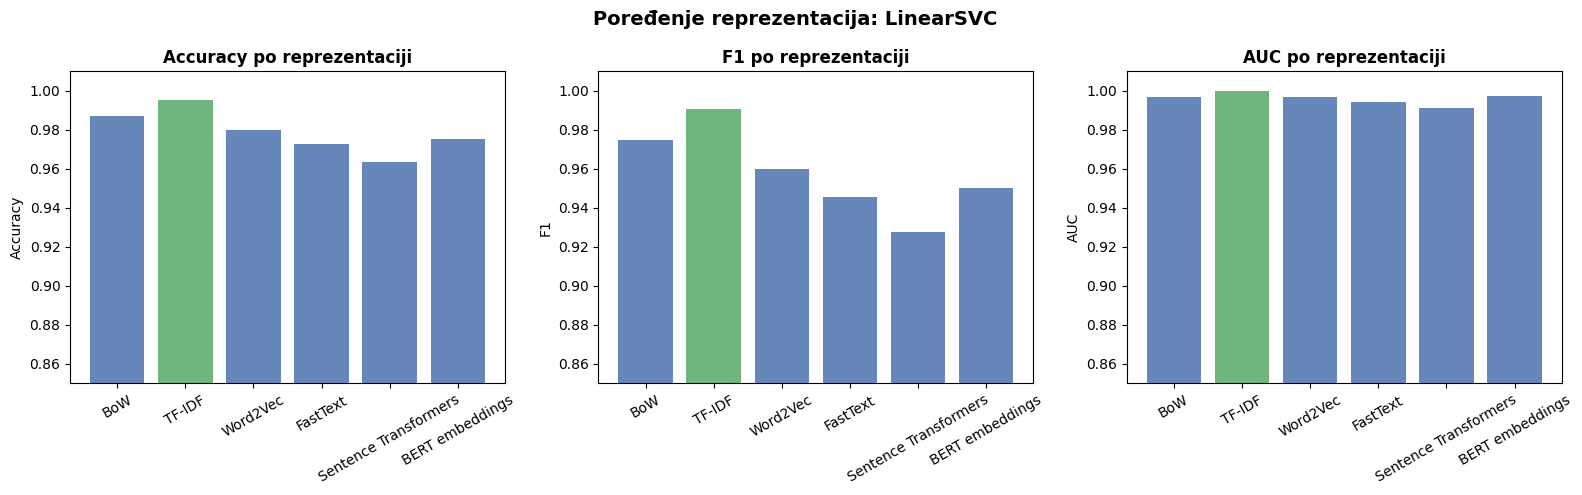

,Reprezentacija,Accuracy,F1,AUC
0,BoW,0.9873,0.9746,0.9970
1,TF-IDF,0.9955,0.9908,0.9998
2,Word2Vec,0.9800,0.9599,0.9967
3,FastText,0.9727,0.9453,0.9944
4,Sentence Transformers,0.9636,0.9275,0.9911
5,BERT embeddings,0.9755,0.9501,0.9973


In [53]:
from sklearn.preprocessing import StandardScaler

repr_results = []

repr_list = [
    ('BoW',                  X_train_bow,  X_test_bow,  False),
    ('TF-IDF',               X_train_tfidf, X_test_tfidf, False),
    ('Word2Vec',             X_train_w2v,  X_test_w2v,  True),
    ('FastText',             X_train_ft,   X_test_ft,   True),
    ('Sentence Transformers',X_train_st,   X_test_st,   True),
    ('BERT embeddings',      X_train_bert, X_test_bert, True),
]

for name, X_tr, X_te, needs_scaling in repr_list:
    if needs_scaling:
        scaler = StandardScaler()
        X_tr_fit = scaler.fit_transform(X_tr)
        X_te_fit = scaler.transform(X_te)
    else:
        X_tr_fit = X_tr
        X_te_fit = X_te

    svc = LinearSVC(max_iter=2000, random_state=42)
    svc.fit(X_tr_fit, y_train)
    y_pred = svc.predict(X_te_fit)
    prob   = svc.decision_function(X_te_fit)

    repr_results.append({
        'Reprezentacija': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1':       round(f1_score(y_test, y_pred), 4),
        'AUC':      round(roc_auc_score(y_test, prob), 4)
    })
    print(f"{name:<25} Acc={repr_results[-1]['Accuracy']:.4f}  "
          f"F1={repr_results[-1]['F1']:.4f}  "
          f"AUC={repr_results[-1]['AUC']:.4f}")

repr_df = pd.DataFrame(repr_results)

# Vizuelizacija
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Accuracy', 'F1', 'AUC']

for ax, metric in zip(axes, metrics):
    colors = ['#55A868' if v == repr_df[metric].max()
              else '#4C72B0' for v in repr_df[metric]]
    ax.bar(repr_df['Reprezentacija'], repr_df[metric],
           color=colors, alpha=0.85)
    ax.set_title(f"{metric} po reprezentaciji", fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0.85, 1.01)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y=0.7609, color='red', linestyle='--',
               alpha=0.5, label='Baseline')

plt.suptitle("Poređenje reprezentacija: LinearSVC",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

display(repr_df.round(4))

### Uticaj predobrade na LinearSVC + TF-IDF

Raw             Acc=0.9927  F1=0.9853  AUC=0.9995
Normalized      Acc=0.9927  F1=0.9853  AUC=0.9997
No stopwords    Acc=0.9955  F1=0.9908  AUC=0.9998
Stemmed         Acc=0.9936  F1=0.9872  AUC=0.9996
Lemmatized      Acc=0.9945  F1=0.9890  AUC=0.9995


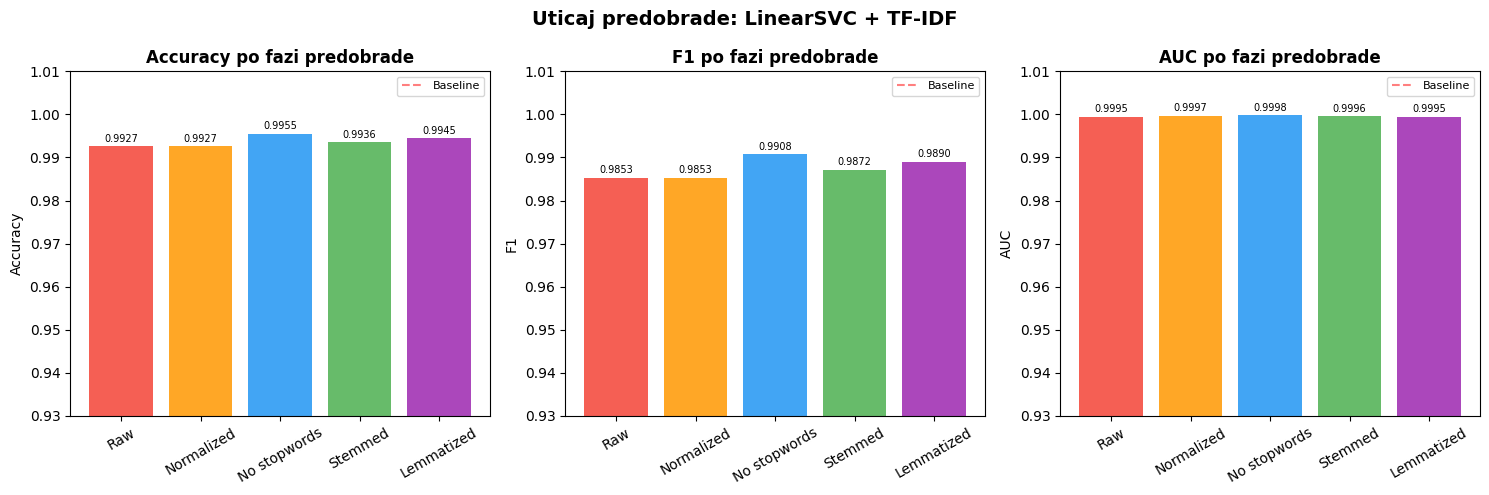

,Predobrada,Accuracy,F1,AUC
0,Raw,0.9927,0.9853,0.9995
1,Normalized,0.9927,0.9853,0.9997
2,No stopwords,0.9955,0.9908,0.9998
3,Stemmed,0.9936,0.9872,0.9996
4,Lemmatized,0.9945,0.9890,0.9995


In [54]:
from sklearn.model_selection import train_test_split

preproc_results = []

preproc_list = [
    ('Raw',          df['text_raw']),
    ('Normalized',   df['text_normalized']),
    ('No stopwords', df['text_no_stop']),
    ('Stemmed',      df['text_stemmed']),
    ('Lemmatized',   df['text_lemmatized']),
]

for name, texts in preproc_list:
    X_tr, X_te, y_tr, y_te = train_test_split(
        texts, df['spam'],
        test_size=0.2, random_state=42, stratify=df['spam']
    )
    vec = TfidfVectorizer(max_features=5000,
                          ngram_range=(1,2), min_df=2)
    X_tr_v = vec.fit_transform(X_tr)
    X_te_v = vec.transform(X_te)

    svc = LinearSVC(max_iter=2000, random_state=42)
    svc.fit(X_tr_v, y_tr)
    y_pred = svc.predict(X_te_v)
    prob   = svc.decision_function(X_te_v)

    preproc_results.append({
        'Predobrada': name,
        'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
        'F1':         round(f1_score(y_te, y_pred), 4),
        'AUC':        round(roc_auc_score(y_te, prob), 4)
    })
    print(f"{name:<15} Acc={preproc_results[-1]['Accuracy']:.4f}  "
          f"F1={preproc_results[-1]['F1']:.4f}  "
          f"AUC={preproc_results[-1]['AUC']:.4f}")

preproc_df = pd.DataFrame(preproc_results)

# Vizuelizacija
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = ['#f44336','#ff9800','#2196F3','#4CAF50','#9C27B0']

for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    bars = ax.bar(preproc_df['Predobrada'],
                  preproc_df[metric],
                  color=bar_colors, alpha=0.85)
    ax.set_title(f"{metric} po fazi predobrade", fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0.93, 1.01)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y=0.7609, color='red', linestyle='--',
               alpha=0.5, label='Baseline')
    ax.legend(fontsize=8)
    # vrednosti iznad barova
    for bar, v in zip(bars, preproc_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 0.001, f'{v:.4f}',
                ha='center', fontsize=7)

plt.suptitle("Uticaj predobrade: LinearSVC + TF-IDF",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

display(preproc_df.round(4))

### Deep Learning: LSTM i CNN

Train shape: (4396, 200)
Test shape : (1100, 200)

Treniranje LSTM...
Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.8127 - loss: 0.5196 - val_accuracy: 0.9364 - val_loss: 0.4431
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.9709 - loss: 0.1378 - val_accuracy: 0.9659 - val_loss: 0.0759
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.9901 - loss: 0.0463 - val_accuracy: 0.9818 - val_loss: 0.0522
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9967 - loss: 0.0168 - val_accuracy: 0.9841 - val_loss: 0.0734
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9977 - loss: 0.0111 - val_accuracy: 0.9818 - val_loss: 0.0782
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

LSTM rezultati:
  Accuracy : 0.9900
  F1       : 0.9799
  AUC      : 0.9993

Treniranje CNN...
Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8195 - loss: 0.3710 - val_accuracy: 0.9727 - val_loss:

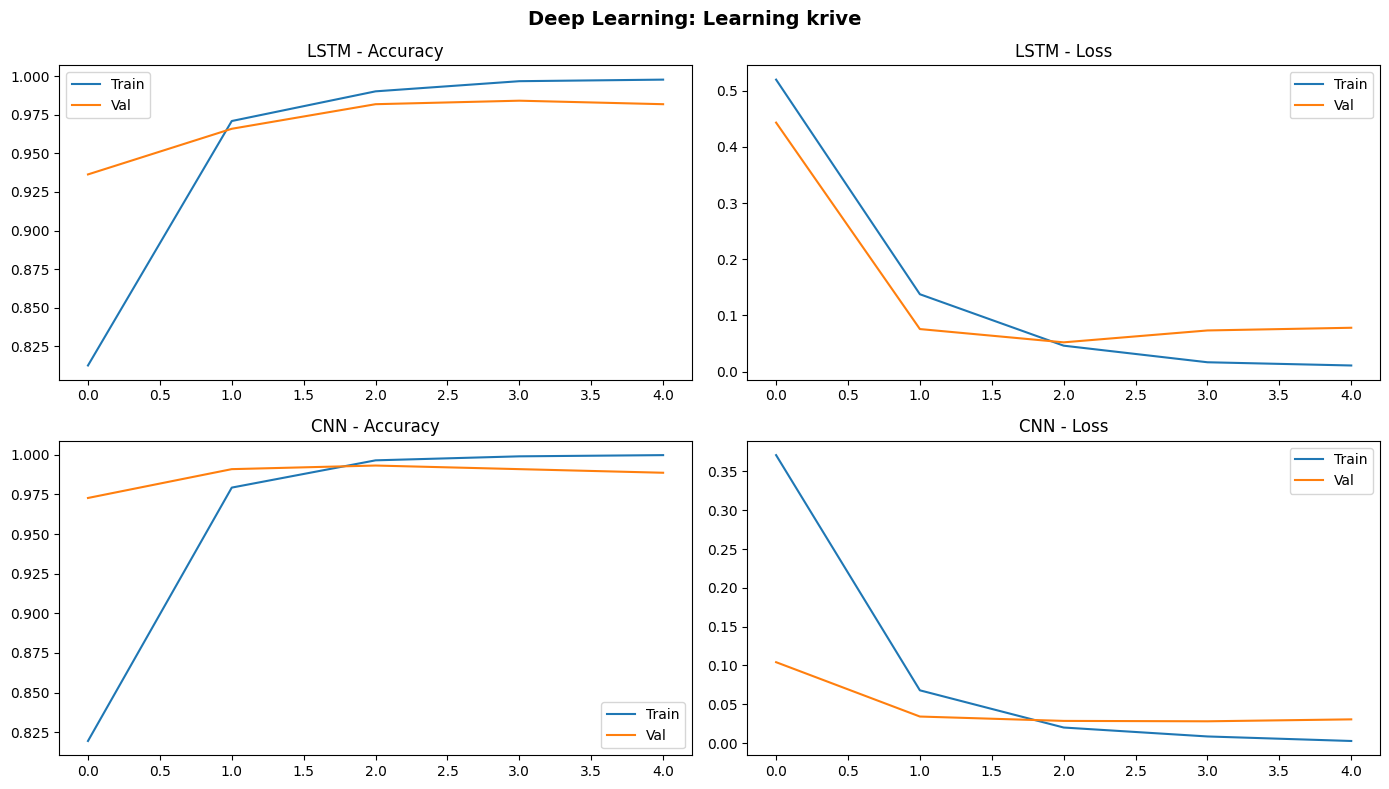

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout, Bidirectional, Conv1D, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 10000
MAX_LEN   = 200
EMBED_DIM = 64

# Tokenizacija
tokenizer_dl = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq  = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape : {X_test_pad.shape}")

# --- LSTM ---
print("\nTreniranje LSTM...")
lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()
y_prob_lstm = lstm_model.predict(X_test_pad).flatten()

acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm)
auc_lstm = roc_auc_score(y_test, y_prob_lstm)

print(f"\nLSTM rezultati:")
print(f"  Accuracy : {acc_lstm:.4f}")
print(f"  F1       : {f1_lstm:.4f}")
print(f"  AUC      : {auc_lstm:.4f}")

# --- CNN ---
print("\nTreniranje CNN...")
cnn_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

y_pred_cnn = (cnn_model.predict(X_test_pad) > 0.5).astype(int).flatten()
y_prob_cnn = cnn_model.predict(X_test_pad).flatten()

acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn  = f1_score(y_test, y_pred_cnn)
auc_cnn = roc_auc_score(y_test, y_prob_cnn)

print(f"\nCNN rezultati:")
print(f"  Accuracy : {acc_cnn:.4f}")
print(f"  F1       : {f1_cnn:.4f}")
print(f"  AUC      : {auc_cnn:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(history_lstm.history['accuracy'], label='Train')
axes[0,0].plot(history_lstm.history['val_accuracy'], label='Val')
axes[0,0].set_title("LSTM - Accuracy"); axes[0,0].legend()

axes[0,1].plot(history_lstm.history['loss'], label='Train')
axes[0,1].plot(history_lstm.history['val_loss'], label='Val')
axes[0,1].set_title("LSTM - Loss"); axes[0,1].legend()

axes[1,0].plot(history_cnn.history['accuracy'], label='Train')
axes[1,0].plot(history_cnn.history['val_accuracy'], label='Val')
axes[1,0].set_title("CNN - Accuracy"); axes[1,0].legend()

axes[1,1].plot(history_cnn.history['loss'], label='Train')
axes[1,1].plot(history_cnn.history['val_loss'], label='Val')
axes[1,1].set_title("CNN - Loss"); axes[1,1].legend()

plt.suptitle("Deep Learning: Learning krive",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### Uticaj augmentacije na performanse

,Model,Augmentacija,F1,Accuracy,Recall
0,Naive Bayes,Bez augmentacije,0.9665,0.9836,0.9524
1,Logistic Regression,Bez augmentacije,0.9662,0.9836,0.9414
2,LinearSVC,Bez augmentacije,0.9908,0.9955,0.9890
3,Naive Bayes,Sa augmentacijom,0.9816,0.9909,0.9780
4,Logistic Regression,Sa augmentacijom,0.9964,0.9982,1.0000
5,LinearSVC,Sa augmentacijom,1.0000,1.0000,1.0000


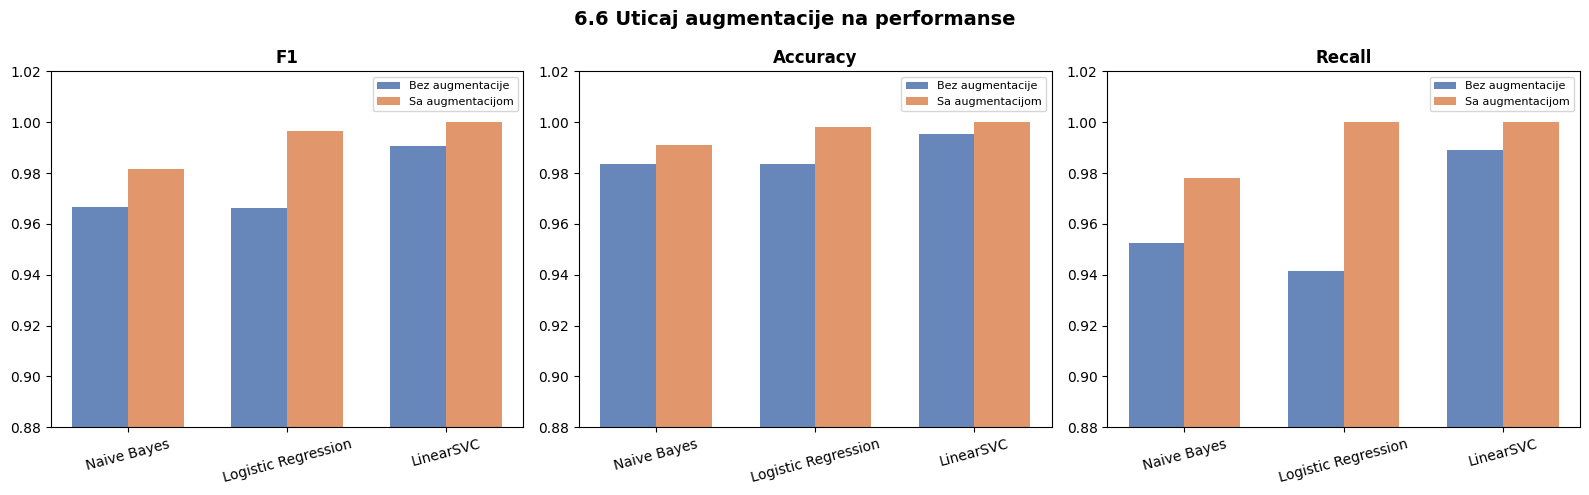

In [56]:
from sklearn.model_selection import train_test_split

aug_results = []

# bez augmentacije (originalni train/test split)
X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    df['text_no_stop'], df['spam'],
    test_size=0.2, random_state=42, stratify=df['spam']
)

vec_o = TfidfVectorizer(max_features=5000,
                        ngram_range=(1,2), min_df=2)
X_tr_o_v = vec_o.fit_transform(X_tr_o)
X_te_o_v = vec_o.transform(X_te_o)

for name, model in [
    ('Naive Bayes',         MultinomialNB()),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('LinearSVC',           LinearSVC(max_iter=2000, random_state=42)),
]:
    model.fit(X_tr_o_v, y_tr_o)
    y_pred = model.predict(X_te_o_v)
    aug_results.append({
        'Model': name,
        'Augmentacija': 'Bez augmentacije',
        'F1':       round(f1_score(y_te_o, y_pred), 4),
        'Accuracy': round(accuracy_score(y_te_o, y_pred), 4),
        'Recall':   round(classification_report(
                        y_te_o, y_pred,
                        output_dict=True)['1']['recall'], 4)
    })

# sa augmentacijom (augmentovani trening skup, isti test skup)
X_aug = df_augmented['text_no_stop']
y_aug = df_augmented['spam']

vec_a = TfidfVectorizer(max_features=5000,
                        ngram_range=(1,2), min_df=2)
X_tr_a_v = vec_a.fit_transform(X_aug)
X_te_a_v = vec_a.transform(X_te_o)  # isti test skup

for name, model in [
    ('Naive Bayes',         MultinomialNB()),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('LinearSVC',           LinearSVC(max_iter=2000, random_state=42)),
]:
    model.fit(X_tr_a_v, y_aug)
    y_pred = model.predict(X_te_a_v)
    aug_results.append({
        'Model': name,
        'Augmentacija': 'Sa augmentacijom',
        'F1':       round(f1_score(y_te_o, y_pred), 4),
        'Accuracy': round(accuracy_score(y_te_o, y_pred), 4),
        'Recall':   round(classification_report(
                        y_te_o, y_pred,
                        output_dict=True)['1']['recall'], 4)
    })

aug_df = pd.DataFrame(aug_results)
display(aug_df.round(4))

# Vizuelizacija
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = aug_df['Model'].unique()
x = np.arange(len(models))
width = 0.35

for ax, metric in zip(axes, ['F1', 'Accuracy', 'Recall']):
    bez = aug_df[aug_df['Augmentacija']=='Bez augmentacije'][metric].values
    sa  = aug_df[aug_df['Augmentacija']=='Sa augmentacijom'][metric].values
    ax.bar(x - width/2, bez, width,
           label='Bez augmentacije', color='#4C72B0', alpha=0.85)
    ax.bar(x + width/2, sa,  width,
           label='Sa augmentacijom', color='#DD8452', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.88, 1.02)
    ax.legend(fontsize=8)

plt.suptitle("6.6 Uticaj augmentacije na performanse",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Finalna komparativna tabela svih modela

,Model,Reprezentacija,Accuracy,F1,AUC
0,LinearSVC,TF-IDF,0.9955,0.9908,0.9998
1,LSTM (Bidirectional),Embedding,0.9900,0.9799,0.9993
2,DistilBERT (fine-tuned),Transformer,0.9891,0.9779,0.9993
3,LinearSVC,BoW,0.9873,0.9746,0.9970
4,Random Forest,TF-IDF,0.9845,0.9687,0.9988
5,Naive Bayes,TF-IDF,0.9836,0.9665,0.9988
6,Logistic Regression,TF-IDF,0.9836,0.9662,0.9993
7,Complement NB,TF-IDF,0.9818,0.9643,0.9988
8,CNN (1D),Embedding,0.9800,0.9603,0.9977
9,LinearSVC,Word2Vec,0.9800,0.9599,0.9967


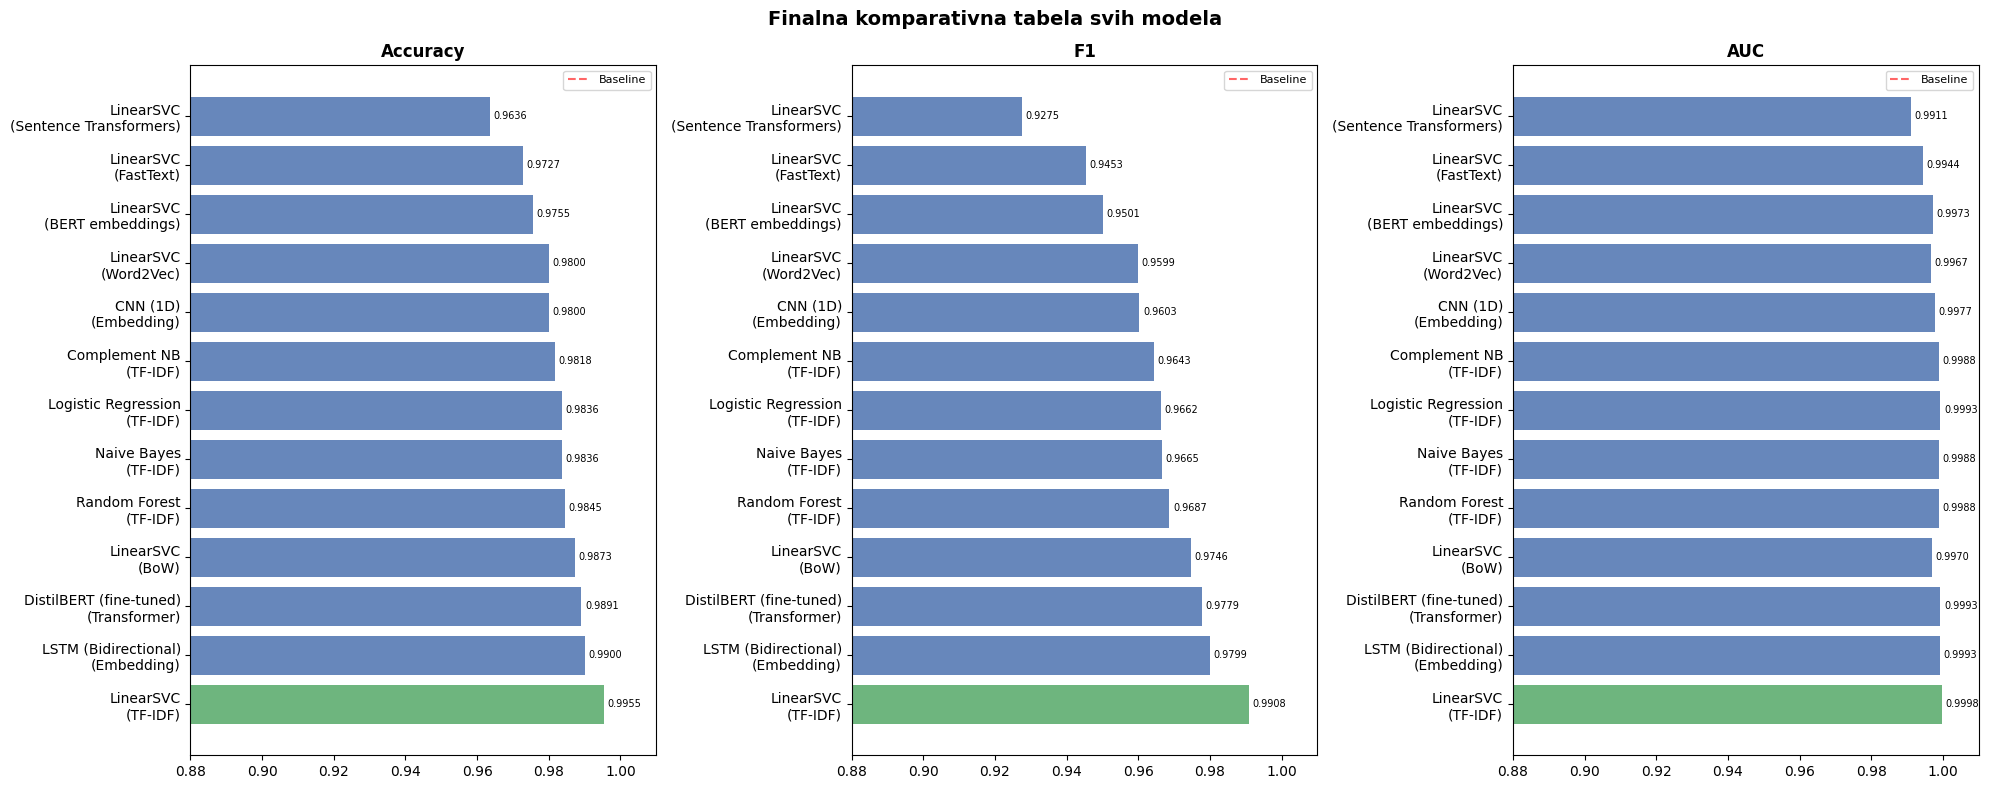

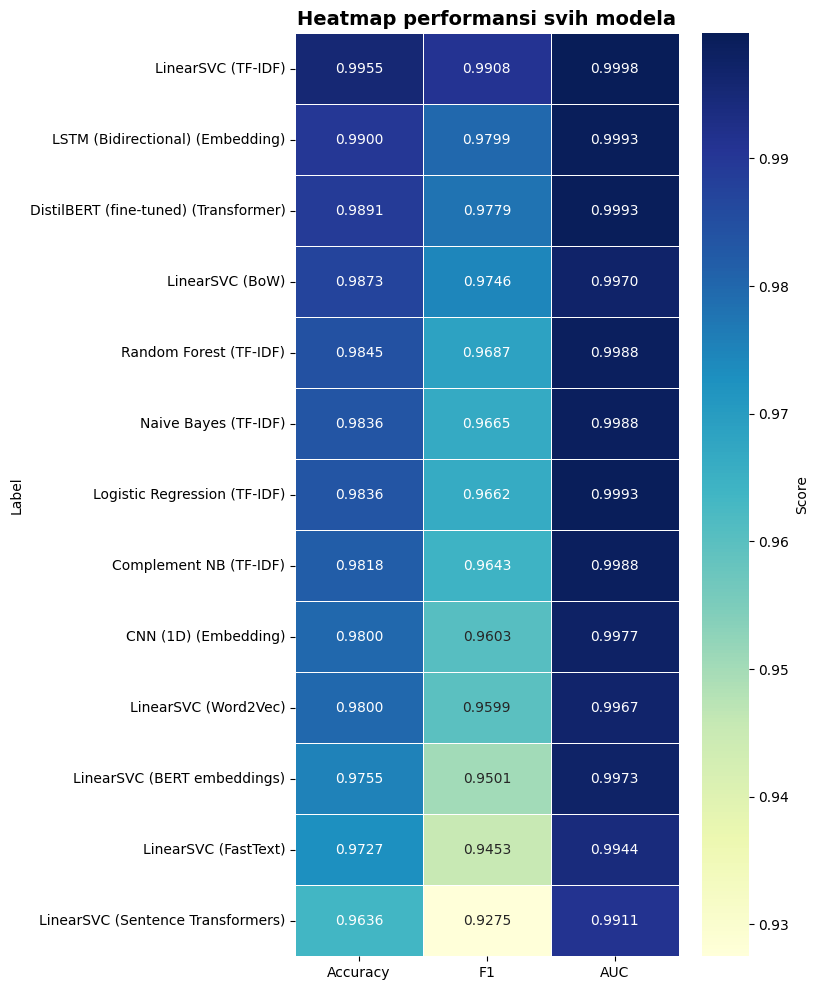


Najbolji model po F1:
  LinearSVC (TF-IDF) — F1=0.9908, AUC=0.9998


In [57]:
final_results = pd.DataFrame([
    # Baseline
    {'Model': 'Baseline (Majority)', 'Reprezentacija': '-',
     'Accuracy': accuracy_score(y_test, y_pred_dummy),
     'F1': 0.0, 'AUC': 0.5},

    *[{'Model': row['Model'], 'Reprezentacija': 'TF-IDF',
       'Accuracy': row['Accuracy'],
       'F1': row['F1'], 'AUC': row['AUC']}
      for _, row in ml_df.iterrows()],

    *[{'Model': f'LinearSVC',
       'Reprezentacija': row['Reprezentacija'],
       'Accuracy': row['Accuracy'],
       'F1': row['F1'], 'AUC': row['AUC']}
      for _, row in repr_df.iterrows()
      if row['Reprezentacija'] != 'TF-IDF'], 

    
    {'Model': 'LSTM (Bidirectional)', 'Reprezentacija': 'Embedding',
     'Accuracy': acc_lstm, 'F1': f1_lstm, 'AUC': auc_lstm},
    {'Model': 'CNN (1D)', 'Reprezentacija': 'Embedding',
     'Accuracy': acc_cnn, 'F1': f1_cnn, 'AUC': auc_cnn},


    {'Model': 'DistilBERT (fine-tuned)', 'Reprezentacija': 'Transformer',
     'Accuracy': acc_bert, 'F1': f1_bert, 'AUC': auc_bert},
])


final_results = final_results.sort_values('F1', ascending=False).reset_index(drop=True)
display(final_results.round(4))

# vizuelizacija
plot_df = final_results[
    final_results['Model'] != 'Baseline (Majority)'
].copy()
plot_df['Label'] = plot_df['Model'] + '\n(' + plot_df['Reprezentacija'] + ')'

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    colors = ['#55A868' if v == plot_df[metric].max()
              else '#4C72B0' for v in plot_df[metric]]
    ax.barh(plot_df['Label'], plot_df[metric],
            color=colors, alpha=0.85)
    ax.axvline(x=0.7609, color='red', linestyle='--',
               alpha=0.6, label='Baseline')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0.88, 1.01)
    ax.legend(fontsize=8)
    for i, v in enumerate(plot_df[metric]):
        ax.text(v + 0.001, i, f'{v:.4f}',
                va='center', fontsize=7)

plt.suptitle("Finalna komparativna tabela svih modela",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# heatmap
heat_df = final_results[
    final_results['Model'] != 'Baseline (Majority)'
].copy()
heat_df['Label'] = heat_df['Model'] + ' (' + heat_df['Reprezentacija'] + ')'
heat_matrix = heat_df.set_index('Label')[['Accuracy', 'F1', 'AUC']]

plt.figure(figsize=(8, 10))
sns.heatmap(heat_matrix, annot=True, fmt='.4f',
            cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Score'})
plt.title("Heatmap performansi svih modela",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNajbolji model po F1:")
best = final_results[final_results['Model'] != 'Baseline (Majority)'].iloc[0]
print(f"  {best['Model']} ({best['Reprezentacija']})"
      f" — F1={best['F1']:.4f}, AUC={best['AUC']:.4f}")

## Finalna komparativna analiza modela

Finalna komparativna analiza obuhvata 13 konfiguracija modela testiranih na istom 
test skupu (1146 emailova, 23.9% spam).

### Ključni zaključci

**1. Najbolji model: LinearSVC + TF-IDF** Najbolje performanse postiže LinearSVC sa TF-IDF reprezentacijom (F1=0.9908, AUC=0.9998), čime nadmašuje sve ostale pristupe, uključujući i duboke modele. Ovo ukazuje da je za ovaj zadatak linearni model uz dobru reprezentaciju potpuno dovoljan.

**2. TF-IDF kao dominantna reprezentacija.** TF-IDF se pokazuje kao najefikasnija reprezentacija teksta. Modeli koji koriste TF-IDF (LinearSVC, Logistic Regression, Naive Bayes) konzistentno postižu vrhunske rezultate. Razlog je što TF-IDF direktno naglašava diskriminativne termine karakteristične za spam (npr. free, click, money), što je ključno za ovaj problem.

**3. Duboki modeli ne donose značajnu prednost** Iako Bidirectional LSTM (F1≈0.98) i fine-tuned DistilBERT (F1≈0.978) postižu veoma dobre rezultate, oni ne nadmašuju LinearSVC + TF-IDF. S obzirom na znatno veću računsku složenost i vreme treniranja, njihova upotreba u ovom slučaju nije opravdana. Ovo sugeriše da zadatak nije semantički kompleksan, već pre svega leksički.

**4. mbedding pristupi slabiji uz jednostavne klasifikatore** Embedding reprezentacije (Word2Vec, FastText, Sentence Transformers, BERT embeddings) u kombinaciji sa LinearSVC daju slabije rezultate (F1 ≈ 0.93–0.96). Razlog je gubitak lokalnih informacija (redosled reči i specifične fraze) usled agregacije (npr. mean pooling), što je kritično za detekciju spam obrazaca.

**5. Stabilno visoke performanse većine modela** Svi testirani modeli značajno nadmašuju baseline (F1=0.0000), pri čemu čak i najslabiji model postiže F1≈0.93. Ovo potvrđuje da je dataset relativno „lak“ za klasifikaciju i da postoji jasan signal u podacima.